# Compréhension globale du projet
## 🎯 Objectif final
```
Créer un dataset d'images propre et homogène pour entraîner un modèle de reconnaissance de déchets (6 classes : cardboard, plastic, paper, glass, metal, trash).

📚 Les 14 parties de l'atelier
Partie	Sujet
0	Structure du projet
1	Exploration du dataset
2	Détection des images corrompues
3	Détection des images vides
4	Détection des différences de résolution
5	Détection des différents canaux
6	Détection des doublons
7	Détection des images mal classées
8	Analyse du déséquilibre des classes
9	Redimensionnement
10	Uniformisation des canaux
11	Mise à l'échelle des pixels
12	Découpage Train/Validation/Test
13	Data Augmentation
14	Bonus
```

# Partie 1 – Exploration du dataset
## 🎯 Objectif
```
Lire toutes les images de chaque dossier et récupérer leurs informations :

Nom, classe, format, mode

Largeur, hauteur

Écart-type des pixels (pour détecter les images vides)

Nombre de canaux

Taille du fichier
```

## 📝 Explication imagée
# C'est comme faire l'inventaire d'un entrepôt :
```
On ouvre chaque carton (dossier)

On note ce qu'il contient (nom, taille, dimensions)

On repère les cartons abîmés (images corrompues)
```

In [9]:
import os
import pandas as pd
import numpy as np
from PIL import Image, ImageStat
import warnings
warnings.filterwarnings('ignore')

# Chemins
BASE_DIR = '../data/raw'
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

print("✅ Bibliothèques importées")
print(f"📁 Dossier de base : {BASE_DIR}")
print(f"📂 Classes : {CLASSES}")

✅ Bibliothèques importées
📁 Dossier de base : ../data/raw
📂 Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


##  Fonction de détection d'image corrompue

In [15]:
def est_corrompue(chemin):
    try:
        with Image.open(chemin) as img:
            img.verify()
        return False
    except Exception:
        return True

In [16]:
def explorer_dataset(base_dir, classes):
    """Parcourt toutes les images et collecte leurs informations."""
    donnees = []
    
    for classe in classes:
        dossier = os.path.join(base_dir, classe)
        if not os.path.exists(dossier):
            print(f"⚠️ Dossier manquant : {dossier}")
            continue
        
        fichiers = os.listdir(dossier)
        print(f"📂 {classe} : {len(fichiers)} fichiers")
        
        for fichier in fichiers:
            chemin = os.path.join(dossier, fichier)
            
            # Ignorer les sous-dossiers
            if not os.path.isfile(chemin):
                continue
            
            # Informations de base
            info = {
                'nom': fichier,
                'classe': classe,
                'chemin': chemin,
                'taille_ko': round(os.path.getsize(chemin) / 1024, 2),
                'corrompue': False,
                'format': None,
                'mode': None,
                'largeur': None,
                'hauteur': None,
                'canaux': None,
                'ecart_type': None
            }
            
            # Vérifier si corrompue
            if est_corrompue(chemin):
                info['corrompue'] = True
                donnees.append(info)
                continue
            
            # Extraire les métadonnées
            try:
                with Image.open(chemin) as img:
                    info['format'] = img.format
                    info['mode'] = img.mode
                    info['largeur'], info['hauteur'] = img.size
                    info['canaux'] = len(img.getbands())
                    
                    # Écart-type des pixels (pour détecter images vides)
                    stat = ImageStat.Stat(img.convert('L'))
                    info['ecart_type'] = round(stat.stddev[0], 2)
            except Exception as e:
                info['corrompue'] = True
            
            donnees.append(info)
    
    return pd.DataFrame(donnees)

# Exécution
df = explorer_dataset(BASE_DIR, CLASSES)

print(f"\n✅ Exploration terminée : {len(df)} images analysées")
print(f"📊 Aperçu :")
df.head()

📂 cardboard : 169 fichiers
📂 glass : 188 fichiers
📂 metal : 149 fichiers
📂 paper : 252 fichiers
📂 plastic : 224 fichiers
📂 trash : 50 fichiers

✅ Exploration terminée : 1032 images analysées
📊 Aperçu :


,nom,classe,chemin,taille_ko,corrompue,format,mode,largeur,hauteur,canaux,ecart_type
0,cardboard1.jpg,cardboard,../data/raw\cardboard\cardboard1.jpg,16.93,False,JPEG,RGB,512.0,384.0,3.0,31.88
1,cardboard10.jpg,cardboard,../data/raw\cardboard\cardboard10.jpg,21.17,False,JPEG,RGB,512.0,384.0,3.0,38.80
2,cardboard100.jpg,cardboard,../data/raw\cardboard\cardboard100.jpg,14.54,False,JPEG,RGB,512.0,384.0,3.0,44.50
3,cardboard101.jpg,cardboard,../data/raw\cardboard\cardboard101.jpg,13.95,False,JPEG,RGB,512.0,384.0,3.0,68.56
4,cardboard102.jpg,cardboard,../data/raw\cardboard\cardboard102.jpg,17.59,False,JPEG,RGB,512.0,384.0,3.0,45.32


### Sauvegarde de l'audit

In [17]:
# Créer le dossier reports s'il n'existe pas
os.makedirs('../reports', exist_ok=True)

# Sauvegarder l'audit
df.to_csv('../reports/audit_images.csv', index=False)

print("✅ Audit sauvegardé dans '../reports/audit_images.csv'")
print(f"📊 Nombre total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

✅ Audit sauvegardé dans '../reports/audit_images.csv'
📊 Nombre total d'images : 1032
❌ Images corrompues : 6


### Statistiques générales

In [18]:
print("=== STATISTIQUES GÉNÉRALES ===\n")

print(f"📊 Total d'images : {len(df)}")
print(f"❌ Images corrompues : {df['corrompue'].sum()}")

print("\n📂 Répartition par classe :")
print(df['classe'].value_counts())

print("\n🎨 Répartition par mode :")
print(df['mode'].value_counts())

print("\n📐 Répartition par nombre de canaux :")
print(df['canaux'].value_counts())

=== STATISTIQUES GÉNÉRALES ===

📊 Total d'images : 1032
❌ Images corrompues : 6

📂 Répartition par classe :
classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

🎨 Répartition par mode :
mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64

📐 Répartition par nombre de canaux :
canaux
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64


### ✅ Vérification

In [19]:
print("=== VÉRIFICATION PARTIE 1 ===")
print(f"✅ DataFrame créé : {df.shape}")
print(f"✅ Colonnes : {list(df.columns)}")
print(f"✅ Fichier CSV sauvegardé : ../reports/audit_images.csv")

=== VÉRIFICATION PARTIE 1 ===
✅ DataFrame créé : (1032, 11)
✅ Colonnes : ['nom', 'classe', 'chemin', 'taille_ko', 'corrompue', 'format', 'mode', 'largeur', 'hauteur', 'canaux', 'ecart_type']
✅ Fichier CSV sauvegardé : ../reports/audit_images.csv


# Partie 2 – Détection des images corrompues
## 🎯 Objectif
### Isoler toutes les images qui ne peuvent pas être lues correctement par Python, pour les exclure du dataset.

**📝 Explication imagée**
C'est comme un contrôle qualité à l'entrée d'une usine :

* On ouvre chaque colis (image)

* Si le colis est abîmé (fichier corrompu), on le met de côté

* Les bons colis continuent leur chemin

* Une image corrompue = un fichier qu'on ne peut pas ouvrir ou lire correctement (fichier tronqué, mauvais format, erreur de téléchargement...).

  ### 1 – Récapitulatif des images corrompues

In [20]:
print("=== IMAGES CORROMPUES ===\n")

# Filtrer les images corrompues
images_corrompues = df[df['corrompue'] == True]

print(f"❌ Nombre d'images corrompues : {len(images_corrompues)}")
print(f"📊 Pourcentage : {len(images_corrompues)/len(df)*100:.2f}%\n")

if len(images_corrompues) > 0:
    print("Liste des images corrompues :")
    print(images_corrompues[['nom', 'classe', 'taille_ko']].to_string(index=False))
else:
    print("✅ Aucune image corrompue détectée !")

=== IMAGES CORROMPUES ===

❌ Nombre d'images corrompues : 6
📊 Pourcentage : 0.58%

Liste des images corrompues :
            nom    classe  taille_ko
cardboard83.jpg cardboard      20.40
    glass74.jpg     glass       7.02
    metal48.jpg     metal       7.09
   paper213.jpg     paper       7.12
  plastic13.jpg   plastic       5.13
     trash3.jpg     trash       8.98


### 2 – Répartition par classe

In [21]:
if len(images_corrompues) > 0:
    print("=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===\n")
    
    repartition = images_corrompues.groupby('classe').size()
    
    for classe, nombre in repartition.items():
        total_classe = len(df[df['classe'] == classe])
        pourcentage = nombre / total_classe * 100
        print(f"📂 {classe:12s} : {nombre:3d} corrompues / {total_classe:4d} total ({pourcentage:.1f}%)")

=== RÉPARTITION DES IMAGES CORROMPUES PAR CLASSE ===

📂 cardboard    :   1 corrompues /  169 total (0.6%)
📂 glass        :   1 corrompues /  188 total (0.5%)
📂 metal        :   1 corrompues /  149 total (0.7%)
📂 paper        :   1 corrompues /  252 total (0.4%)
📂 plastic      :   1 corrompues /  224 total (0.4%)
📂 trash        :   1 corrompues /   50 total (2.0%)


### 3 – Création du dataset propre (sans corrompues)

In [22]:
# Dataset sans les images corrompues
df_propre = df[df['corrompue'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===\n")
print(f"📊 Avant : {len(df)} images")
print(f"📊 Après : {len(df_propre)} images")
print(f"🗑️  Supprimées : {len(df) - len(df_propre)} images")
print(f"✅ Pourcentage conservé : {len(df_propre)/len(df)*100:.2f}%")

# Sauvegarder cette version
df_propre.to_csv('../reports/audit_images_sans_corrompues.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES CORROMPUES ===

📊 Avant : 1032 images
📊 Après : 1026 images
🗑️  Supprimées : 6 images
✅ Pourcentage conservé : 99.42%

💾 Sauvegardé dans '../reports/audit_images_sans_corrompues.csv'


### 4 – Visualisation 

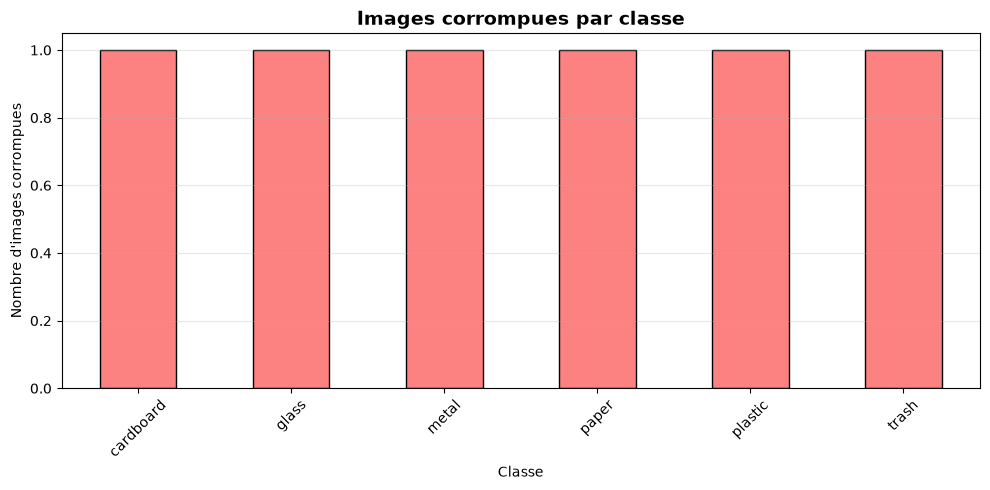

💾 Graphique sauvegardé dans '../reports/images_corrompues.png'


In [23]:
import matplotlib.pyplot as plt

if len(images_corrompues) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    repartition = images_corrompues.groupby('classe').size()
    repartition.plot(kind='bar', color='#fc8181', edgecolor='black', ax=ax)
    
    ax.set_title('Images corrompues par classe', fontsize=14, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Nombre d\'images corrompues')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/images_corrompues.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("💾 Graphique sauvegardé dans '../reports/images_corrompues.png'")

```
Dataset original (100%)
        │
        ▼
┌───────────────────────┐
│  Images corrompues ?  │
└───────────────────────┘
        │
    ┌───┴───┐
    │       │
   OUI     NON
    │       │
    ▼       ▼
  🗑️      ✅
Supprimer  Conserver
            │
            ▼
    Dataset propre
```

### ✅ Vérification

In [24]:
print("=== VÉRIFICATION PARTIE 2 ===")
print(f"✅ Fonction de détection : est_corrompue()")
print(f"✅ Images corrompues identifiées : {len(images_corrompues)}")
print(f"✅ Dataset propre : {len(df_propre)} images conservées")
print(f"✅ Fichier sauvegardé : audit_images_sans_corrompues.csv")

=== VÉRIFICATION PARTIE 2 ===
✅ Fonction de détection : est_corrompue()
✅ Images corrompues identifiées : 6
✅ Dataset propre : 1026 images conservées
✅ Fichier sauvegardé : audit_images_sans_corrompues.csv


# Partie 3 – Détection des images vides

## 🎯 Objectif
Identifier les images qui ne contiennent **aucune information utile** : 
- Images entièrement noires
- Images entièrement blanches
- Images avec très peu de variation de pixels (unies)

## 📝 Explication imagée

C'est comme vérifier qu'une **photo n'est pas un écran noir** :
- Une image **noire** = pixels tous à 0 (aucune information)
- Une image **blanche** = pixels tous à 255 (aucune information)
- Une image **unie** = pixels presque identiques (très peu de variation)

**Comment détecter ?** On utilise l'**écart-type** des pixels :
- Écart-type proche de **0** → image vide ou unie
- Écart-type élevé → image avec du contenu

# Fonction de détection d'image vide

In [25]:
def est_vide(chemin, seuil_ecart_type=10, seuil_extremes=0.98):
    """
    Détecte si une image est vide ou quasi-vide.
    
    Paramètres:
    -----------
    chemin : str - Chemin de l'image
    seuil_ecart_type : float - Écart-type minimum pour considérer l'image comme non vide
    seuil_extremes : float - Proportion de pixels noirs/blancs pour considérer l'image comme vide
    
    Retourne:
    --------
    tuple : (est_vide, raison)
    """
    try:
        with Image.open(chemin) as img:
            # Convertir en niveaux de gris pour simplifier
            img_gris = img.convert('L')
            pixels = np.array(img_gris)
            
            # 1. Vérifier l'écart-type (variation des pixels)
            ecart_type = np.std(pixels)
            if ecart_type < seuil_ecart_type:
                return True, f"Écart-type faible ({ecart_type:.2f})"
            
            # 2. Vérifier la proportion de pixels noirs ou blancs
            total_pixels = pixels.size
            pixels_noirs = np.sum(pixels < 10) / total_pixels
            pixels_blancs = np.sum(pixels > 245) / total_pixels
            
            if pixels_noirs > seuil_extremes:
                return True, f"Image presque entièrement noire ({pixels_noirs*100:.1f}%)"
            if pixels_blancs > seuil_extremes:
                return True, f"Image presque entièrement blanche ({pixels_blancs*100:.1f}%)"
            
            return False, "OK"
    
    except Exception as e:
        return True, f"Erreur : {e}"

### Application de la détection sur le dataset

On applique la fonction `est_vide()` à toutes les images du dataset propre.

In [26]:
# Appliquer la détection sur le dataset propre
resultats_vides = df_propre['chemin'].apply(lambda x: est_vide(x))

# Extraire les résultats
df_propre['est_vide'] = resultats_vides.apply(lambda x: x[0])
df_propre['raison_vide'] = resultats_vides.apply(lambda x: x[1])

# Nombre d'images vides
nb_vides = df_propre['est_vide'].sum()

print("=== DÉTECTION DES IMAGES VIDES ===\n")
print(f"📊 Total d'images analysées : {len(df_propre)}")
print(f"⚠️  Images vides détectées : {nb_vides}")
print(f"✅ Images valides : {len(df_propre) - nb_vides}")
print(f"📈 Pourcentage d'images vides : {nb_vides/len(df_propre)*100:.2f}%")

=== DÉTECTION DES IMAGES VIDES ===

📊 Total d'images analysées : 1026
⚠️  Images vides détectées : 10
✅ Images valides : 1016
📈 Pourcentage d'images vides : 0.97%


### Détail des images vides

Affichons la liste des images considérées comme vides avec la raison.

In [27]:
images_vides = df_propre[df_propre['est_vide'] == True]

if len(images_vides) > 0:
    print("=== DÉTAIL DES IMAGES VIDES ===\n")
    print(images_vides[['nom', 'classe', 'ecart_type', 'raison_vide']].to_string(index=False))
    
    print("\n📊 Répartition par classe :")
    print(images_vides.groupby('classe').size())
else:
    print("✅ Aucune image vide détectée !")

=== DÉTAIL DES IMAGES VIDES ===

                      nom    classe  ecart_type              raison_vide
image-blanche-512x384.jpg cardboard        1.13 Écart-type faible (1.13)
             glass178.jpg     glass        9.75 Écart-type faible (9.75)
  image-noire-512x384.png     glass        0.00 Écart-type faible (0.00)
image-blanche-512x384.jpg     metal        1.13 Écart-type faible (1.13)
  image-noire-512x384.png     metal        0.00 Écart-type faible (0.00)
            plastic12.jpg   plastic        9.26 Écart-type faible (9.26)
           plastic147.jpg   plastic        8.41 Écart-type faible (8.41)
           plastic150.jpg   plastic        7.49 Écart-type faible (7.49)
             plastic2.jpg   plastic        8.59 Écart-type faible (8.59)
             plastic3.jpg   plastic        7.98 Écart-type faible (7.98)

📊 Répartition par classe :
classe
cardboard    1
glass        2
metal        2
plastic      5
dtype: int64


### Visualisation (optionnel)

On peut afficher quelques images vides pour vérifier visuellement.

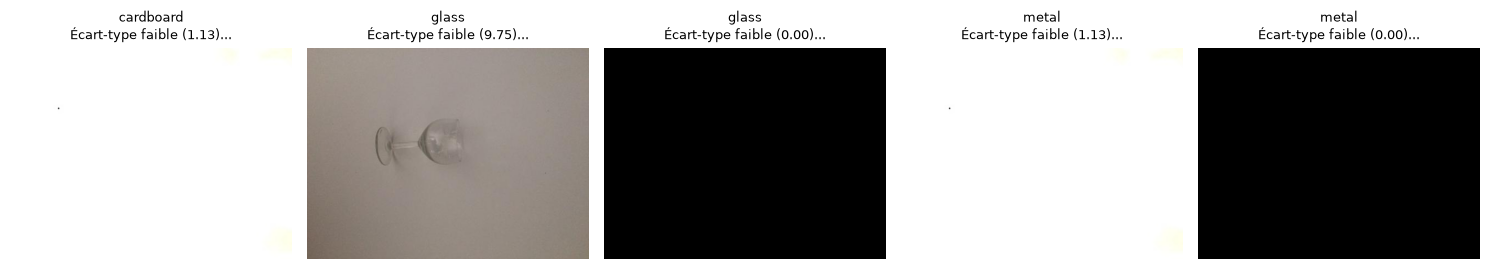

💾 Graphique sauvegardé dans '../reports/images_vides.png'


In [28]:
import matplotlib.pyplot as plt

if len(images_vides) > 0:
    # Afficher jusqu'à 5 images vides
    nb_a_afficher = min(5, len(images_vides))
    fig, axes = plt.subplots(1, nb_a_afficher, figsize=(15, 4))
    
    if nb_a_afficher == 1:
        axes = [axes]
    
    for i, (idx, row) in enumerate(images_vides.head(nb_a_afficher).iterrows()):
        try:
            img = Image.open(row['chemin'])
            axes[i].imshow(img)
            axes[i].set_title(f"{row['classe']}\n{row['raison_vide'][:30]}...", fontsize=9)
            axes[i].axis('off')
        except:
            axes[i].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('../reports/images_vides.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Graphique sauvegardé dans '../reports/images_vides.png'")

### Création du dataset sans images vides

On retire les images vides du dataset pour ne garder que les images utiles.

In [29]:
# Dataset sans les images vides
df_sans_vides = df_propre[df_propre['est_vide'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES VIDES ===\n")
print(f"📊 Avant : {len(df_propre)} images")
print(f"📊 Après : {len(df_sans_vides)} images")
print(f"🗑️  Supprimées : {len(df_propre) - len(df_sans_vides)} images")

# Sauvegarder
df_sans_vides.to_csv('../reports/audit_images_sans_vides.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_vides.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES VIDES ===

📊 Avant : 1026 images
📊 Après : 1016 images
🗑️  Supprimées : 10 images

💾 Sauvegardé dans '../reports/audit_images_sans_vides.csv'


In [30]:
print("=== VÉRIFICATION PARTIE 3 ===")
print(f"✅ Fonction de détection : est_vide()")
print(f"✅ Images vides identifiées : {nb_vides}")
print(f"✅ Dataset final : {len(df_sans_vides)} images")
print(f"✅ Fichier sauvegardé : audit_images_sans_vides.csv")

=== VÉRIFICATION PARTIE 3 ===
✅ Fonction de détection : est_vide()
✅ Images vides identifiées : 10
✅ Dataset final : 1016 images
✅ Fichier sauvegardé : audit_images_sans_vides.csv


# Partie 4 – Détection des différences de résolution

## 🎯 Objectif
Analyser les **dimensions** (largeur × hauteur) de toutes les images pour :
1. Déterminer la résolution minimale, maximale et les plus fréquentes
2. Identifier les images trop petites (< 64 × 64 pixels)

## 📝 Explication imagée

C'est comme mesurer la **taille des vêtements** dans un lot :
- Certains sont trop petits (XS)
- D'autres sont immenses (XXL)
- La plupart sont standards (M)

**Problème** : Un modèle de Deep Learning a besoin d'images **de même taille** pour apprendre correctement. On doit donc détecter les tailles pour ensuite les uniformiser.

In [31]:
# Créer une colonne "résolution" (largeur x hauteur)
df_sans_vides['resolution'] = df_sans_vides['largeur'].astype(str) + 'x' + df_sans_vides['hauteur'].astype(str)

# Statistiques générales
print("=== STATISTIQUES DES RÉSOLUTIONS ===\n")

print(f"📐 Largeur minimale  : {df_sans_vides['largeur'].min()} px")
print(f"📐 Largeur maximale  : {df_sans_vides['largeur'].max()} px")
print(f"📐 Hauteur minimale  : {df_sans_vides['hauteur'].min()} px")
print(f"📐 Hauteur maximale  : {df_sans_vides['hauteur'].max()} px")

print(f"\n📊 Largeur moyenne : {df_sans_vides['largeur'].mean():.0f} px")
print(f"📊 Hauteur moyenne : {df_sans_vides['hauteur'].mean():.0f} px")

=== STATISTIQUES DES RÉSOLUTIONS ===

📐 Largeur minimale  : 32.0 px
📐 Largeur maximale  : 512.0 px
📐 Hauteur minimale  : 32.0 px
📐 Hauteur maximale  : 384.0 px

📊 Largeur moyenne : 506 px
📊 Hauteur moyenne : 380 px


### Résolutions les plus fréquentes

On compte combien d'images partagent la même résolution.

In [32]:
print("=== TOP 10 DES RÉSOLUTIONS LES PLUS FRÉQUENTES ===\n")

top_resolutions = df_sans_vides['resolution'].value_counts().head(10)

for resolution, nombre in top_resolutions.items():
    pourcentage = nombre / len(df_sans_vides) * 100
    print(f"📐 {resolution:15s} : {nombre:4d} images ({pourcentage:5.2f}%)")

=== TOP 10 DES RÉSOLUTIONS LES PLUS FRÉQUENTES ===

📐 512.0x384.0     : 1003 images (98.72%)
📐 32.0x32.0       :    5 images ( 0.49%)
📐 48.0x32.0       :    4 images ( 0.39%)
📐 40.0x40.0       :    4 images ( 0.39%)


### Détection des images trop petites

**Contrainte** : Une image doit avoir au minimum **64 × 64 pixels**.

Une image plus petite que 64×64 est considérée comme **trop petite** pour être utile.

In [33]:
# Taille minimale acceptée
TAILLE_MIN = 64

# Détecter les images trop petites
df_sans_vides['trop_petite'] = (
    (df_sans_vides['largeur'] < TAILLE_MIN) | 
    (df_sans_vides['hauteur'] < TAILLE_MIN)
)

images_trop_petites = df_sans_vides[df_sans_vides['trop_petite'] == True]

print("=== IMAGES TROP PETITES ===\n")
print(f"📏 Taille minimale acceptée : {TAILLE_MIN}×{TAILLE_MIN} px")
print(f"⚠️  Images trop petites : {len(images_trop_petites)}")
print(f"📈 Pourcentage : {len(images_trop_petites)/len(df_sans_vides)*100:.2f}%")

if len(images_trop_petites) > 0:
    print("\nDétail des images trop petites :")
    print(images_trop_petites[['nom', 'classe', 'largeur', 'hauteur']].head(10).to_string(index=False))

=== IMAGES TROP PETITES ===

📏 Taille minimale acceptée : 64×64 px
⚠️  Images trop petites : 13
📈 Pourcentage : 1.28%

Détail des images trop petites :
             nom    classe  largeur  hauteur
cardboard117.jpg cardboard     48.0     32.0
 cardboard22.jpg cardboard     32.0     32.0
 cardboard70.jpg cardboard     40.0     40.0
    glass100.jpg     glass     40.0     40.0
     glass15.jpg     glass     48.0     32.0
     glass21.jpg     glass     32.0     32.0
     glass23.jpg     glass     32.0     32.0
    metal121.jpg     metal     48.0     32.0
      metal2.jpg     metal     32.0     32.0
     metal26.jpg     metal     40.0     40.0


### Visualisation des résolutions

Histogramme des largeurs et hauteurs pour voir la distribution.

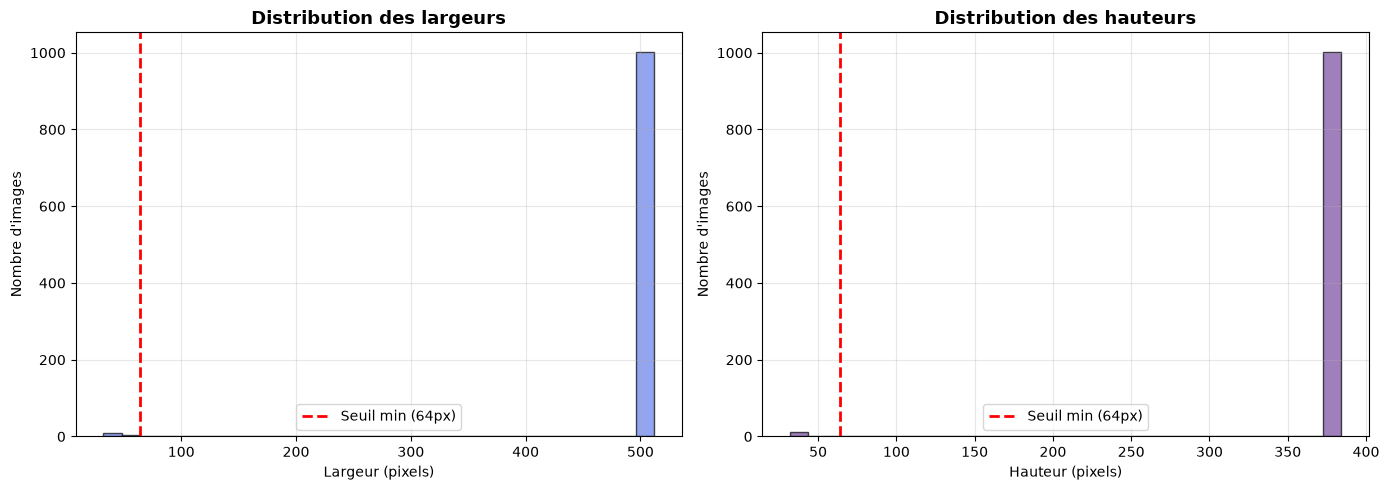

💾 Graphique sauvegardé dans '../reports/distribution_resolutions.png'


In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des largeurs
axes[0].hist(df_sans_vides['largeur'], bins=30, color='#667eea', edgecolor='black', alpha=0.7)
axes[0].axvline(x=TAILLE_MIN, color='red', linestyle='--', linewidth=2, label=f'Seuil min ({TAILLE_MIN}px)')
axes[0].set_title('Distribution des largeurs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Largeur (pixels)')
axes[0].set_ylabel('Nombre d\'images')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des hauteurs
axes[1].hist(df_sans_vides['hauteur'], bins=30, color='#764ba2', edgecolor='black', alpha=0.7)
axes[1].axvline(x=TAILLE_MIN, color='red', linestyle='--', linewidth=2, label=f'Seuil min ({TAILLE_MIN}px)')
axes[1].set_title('Distribution des hauteurs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hauteur (pixels)')
axes[1].set_ylabel('Nombre d\'images')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/distribution_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/distribution_resolutions.png'")

### Dataset final sans images trop petites

On retire les images trop petites pour ne garder que celles exploitables.

In [36]:
# Dataset sans les images trop petites
df_sans_petites = df_sans_vides[df_sans_vides['trop_petite'] == False].copy()

print("=== DATASET APRÈS SUPPRESSION DES IMAGES TROP PETITES ===\n")
print(f"📊 Avant : {len(df_sans_vides)} images")
print(f"📊 Après : {len(df_sans_petites)} images")
print(f"🗑️  Supprimées : {len(df_sans_vides) - len(df_sans_petites)} images")

# Sauvegarder
df_sans_petites.to_csv('../reports/audit_images_sans_petites.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_petites.csv'")

=== DATASET APRÈS SUPPRESSION DES IMAGES TROP PETITES ===

📊 Avant : 1016 images
📊 Après : 1003 images
🗑️  Supprimées : 13 images

💾 Sauvegardé dans '../reports/audit_images_sans_petites.csv'


In [37]:
print("=== VÉRIFICATION PARTIE 4 ===")
print(f"✅ Résolution min : {df_sans_petites['largeur'].min()}×{df_sans_petites['hauteur'].min()}")
print(f"✅ Résolution max : {df_sans_petites['largeur'].max()}×{df_sans_petites['hauteur'].max()}")
print(f"✅ Images trop petites supprimées : {len(images_trop_petites)}")
print(f"✅ Dataset final : {len(df_sans_petites)} images")

=== VÉRIFICATION PARTIE 4 ===
✅ Résolution min : 512.0×384.0
✅ Résolution max : 512.0×384.0
✅ Images trop petites supprimées : 13
✅ Dataset final : 1003 images


# Partie 5 – Détection des différents canaux

## 🎯 Objectif
Identifier combien d'images sont en :
- **RGB** (3 canaux : Rouge, Vert, Bleu) → images couleur normales
- **RGBA** (4 canaux : RGB + Alpha/transparence)
- **L** (1 canal : niveaux de gris)
- **Autres** (CMYK, P, etc.)

## 📝 Explication imagée

C'est comme trier des **télévisions** selon leur type d'image :
- **Couleur** (RGB) → TV moderne
- **Couleur + transparence** (RGBA) → TV avec fonction spéciale
- **Noir et blanc** (L) → vieux poste
- **Autres** → formats exotiques

**Problème** : Un modèle de Deep Learning attend des images avec **le même nombre de canaux**. Il faut donc uniformiser tout ça.

In [38]:
print("=== ANALYSE DES CANAUX ===\n")

# Distribution des modes
modes = df_sans_petites['mode'].value_counts()

print("📊 Répartition par mode :")
for mode, nombre in modes.items():
    pourcentage = nombre / len(df_sans_petites) * 100
    print(f"   {mode:6s} : {nombre:5d} images ({pourcentage:6.2f}%)")

print("\n📊 Répartition par nombre de canaux :")
canaux = df_sans_petites['canaux'].value_counts()
for canal, nombre in canaux.items():
    pourcentage = nombre / len(df_sans_petites) * 100
    print(f"   {canal} canal(aux) : {nombre:5d} images ({pourcentage:6.2f}%)")

=== ANALYSE DES CANAUX ===

📊 Répartition par mode :
   RGB    :   985 images ( 98.21%)
   RGBA   :    16 images (  1.60%)
   P      :     2 images (  0.20%)

📊 Répartition par nombre de canaux :
   3.0 canal(aux) :   985 images ( 98.21%)
   4.0 canal(aux) :    16 images (  1.60%)
   1.0 canal(aux) :     2 images (  0.20%)


### Détail des canaux par classe

On regarde si certaines classes ont plus d'images en niveaux de gris que d'autres.

In [39]:
print("=== CANAUX PAR CLASSE ===\n")

# Tableau croisé classe × mode
tableau = pd.crosstab(df_sans_petites['classe'], df_sans_petites['mode'])
print(tableau)

=== CANAUX PAR CLASSE ===

mode       P  RGB  RGBA
classe                 
cardboard  1  157     6
glass      1  174     6
metal      0  139     4
paper      0  248     0
plastic    0  218     0
trash      0   49     0


### Identification des images non-RGB

On isole les images qui **ne sont pas en RGB** (elles devront être converties plus tard).

In [40]:
# Images qui ne sont pas en RGB
images_non_rgb = df_sans_petites[df_sans_petites['mode'] != 'RGB']

print("=== IMAGES NON-RGB ===\n")
print(f"⚠️  Nombre d'images non-RGB : {len(images_non_rgb)}")
print(f"📈 Pourcentage : {len(images_non_rgb)/len(df_sans_petites)*100:.2f}%")

if len(images_non_rgb) > 0:
    print("\nRépartition des modes non-RGB :")
    print(images_non_rgb['mode'].value_counts())
    
    print("\nExemples :")
    print(images_non_rgb[['nom', 'classe', 'mode', 'canaux']].head(10).to_string(index=False))

=== IMAGES NON-RGB ===

⚠️  Nombre d'images non-RGB : 18
📈 Pourcentage : 1.79%

Répartition des modes non-RGB :
mode
RGBA    16
P        2
Name: count, dtype: int64

Exemples :
                     nom    classe mode  canaux
        cardboard13v.png cardboard RGBA     4.0
        cardboard25g.png cardboard RGBA     4.0
       cardboard35tg.png cardboard RGBA     4.0
         cardboard4g.png cardboard RGBA     4.0
       cardboard50rg.png cardboard RGBA     4.0
        cardboard85g.png cardboard RGBA     4.0
image-violet-512x384.gif cardboard    P     1.0
           glass109g.png     glass RGBA     4.0
           glass117g.png     glass RGBA     4.0
            glass11g.png     glass RGBA     4.0


### Visualisation

Graphique de la répartition des modes pour mieux visualiser.

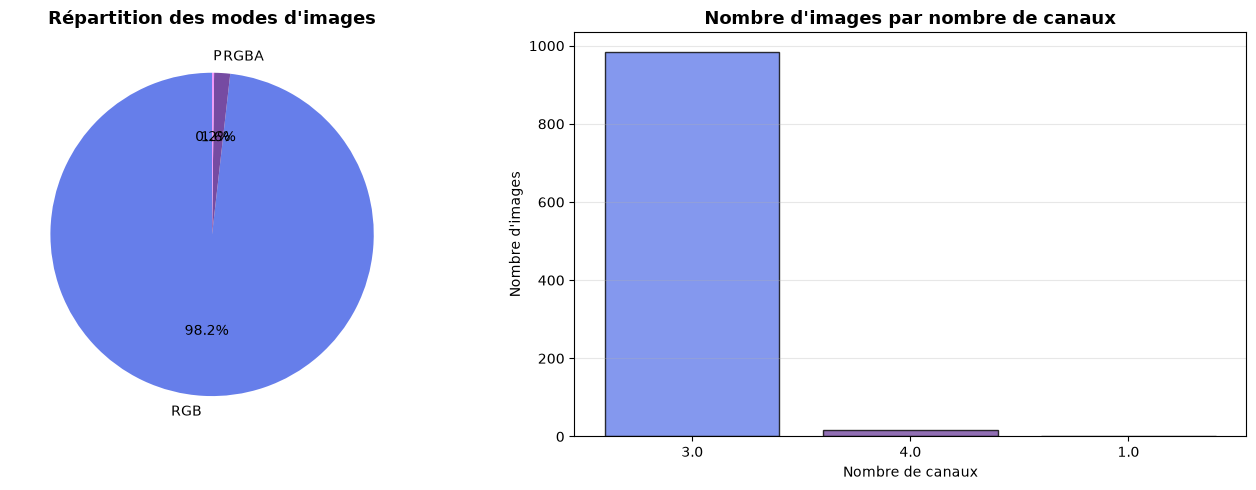

💾 Graphique sauvegardé dans '../reports/distribution_canaux.png'


In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Camembert des modes
modes = df_sans_petites['mode'].value_counts()
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b'][:len(modes)]
axes[0].pie(modes.values, labels=modes.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Répartition des modes d\'images', fontsize=13, fontweight='bold')

# Barres des canaux
canaux = df_sans_petites['canaux'].value_counts()
axes[1].bar(canaux.index.astype(str), canaux.values, 
            color=['#667eea', '#764ba2', '#f093fb'][:len(canaux)], 
            edgecolor='black', alpha=0.8)
axes[1].set_title('Nombre d\'images par nombre de canaux', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de canaux')
axes[1].set_ylabel('Nombre d\'images')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/distribution_canaux.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/distribution_canaux.png'")

### Préparation pour l'uniformisation

On note les images à convertir plus tard (Partie 10).
Pour l'instant, on garde tout le monde mais on **identifie** ce qui devra être changé.

In [42]:
# Sauvegarder l'audit complet
df_sans_petites.to_csv('../reports/audit_images_final.csv', index=False)

print("=== RÉCAPITULATIF DES CANAUX ===\n")
print(f"✅ Images RGB   : {len(df_sans_petites[df_sans_petites['mode'] == 'RGB'])}")
print(f"✅ Images RGBA  : {len(df_sans_petites[df_sans_petites['mode'] == 'RGBA'])}")
print(f"✅ Images L     : {len(df_sans_petites[df_sans_petites['mode'] == 'L'])}")
print(f"⚠️  Autres      : {len(df_sans_petites[~df_sans_petites['mode'].isin(['RGB', 'RGBA', 'L'])])}")
print(f"\n📊 Total       : {len(df_sans_petites)} images")
print(f"\n💾 Audit sauvegardé dans '../reports/audit_images_final.csv'")

=== RÉCAPITULATIF DES CANAUX ===

✅ Images RGB   : 985
✅ Images RGBA  : 16
✅ Images L     : 0
⚠️  Autres      : 2

📊 Total       : 1003 images

💾 Audit sauvegardé dans '../reports/audit_images_final.csv'


In [43]:
print("=== VÉRIFICATION PARTIE 5 ===")
print(f"✅ Modes identifiés : {df_sans_petites['mode'].unique().tolist()}")
print(f"✅ Canaux identifiés : {sorted(df_sans_petites['canaux'].unique().tolist())}")
print(f"✅ Images non-RGB à convertir : {len(images_non_rgb)}")

=== VÉRIFICATION PARTIE 5 ===
✅ Modes identifiés : ['RGB', 'RGBA', 'P']
✅ Canaux identifiés : [1.0, 3.0, 4.0]
✅ Images non-RGB à convertir : 18


# Partie 6 – Détection des doublons

## 🎯 Objectif
Identifier les images **identiques** présentes plusieurs fois dans le dataset, même si elles ont des **noms de fichiers différents**.

## 📝 Explication imagée

C'est comme chercher des **vrais jumeaux** dans une foule :
- Ils peuvent porter des vêtements différents (noms de fichiers différents)
- Mais leur visage est identique (même contenu binaire)

**Méthode** : On calcule une **empreinte unique** (hash MD5) pour chaque image :
- Si deux images ont la même empreinte → ce sont des doublons
- Le hash est comme une **empreinte digitale** du fichier

**Attention** : Deux fichiers différents peuvent contenir exactement la même image !

In [44]:
import hashlib

def calculer_hash(chemin):
    """Calcule l'empreinte MD5 d'un fichier image."""
    try:
        with open(chemin, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception as e:
        return None

### Application de la détection sur le dataset

On calcule le hash de chaque image pour identifier les doublons.

In [46]:
# Calculer le hash de chaque image
df_sans_petites['hash'] = df_sans_petites['chemin'].apply(calculer_hash)

print("=== CALCUL DES EMPREINTES ===\n")
print(f"📊 Total d'images : {len(df_sans_petites)}")
print(f"✅ Hash calculés : {df_sans_petites['hash'].notna().sum()}")
print(f"❌ Hash échoués : {df_sans_petites['hash'].isna().sum()}")

=== CALCUL DES EMPREINTES ===

📊 Total d'images : 1003
✅ Hash calculés : 1003
❌ Hash échoués : 0


### Identification des doublons

On regroupe les images par hash. Si un hash apparaît plusieurs fois → doublons.

In [47]:
# Compter les occurrences de chaque hash
hash_counts = df_sans_petites['hash'].value_counts()

# Hash qui apparaissent plus d'une fois = doublons
hash_doublons = hash_counts[hash_counts > 1]

print("=== DÉTECTION DES DOUBLONS ===\n")
print(f"🔍 Nombre de hash uniques : {len(hash_counts)}")
print(f"⚠️  Nombre de groupes de doublons : {len(hash_doublons)}")
print(f"📊 Total d'images en doublon : {hash_doublons.sum() - len(hash_doublons)}")

# Nombre total d'images à supprimer (garder 1 par groupe)
nb_a_supprimer = hash_doublons.sum() - len(hash_doublons)
print(f"🗑️  Images à supprimer : {nb_a_supprimer}")

=== DÉTECTION DES DOUBLONS ===

🔍 Nombre de hash uniques : 990
⚠️  Nombre de groupes de doublons : 13
📊 Total d'images en doublon : 13
🗑️  Images à supprimer : 13


### Détail des groupes de doublons

Affichons les images qui sont dupliquées avec leurs noms et classes.

In [48]:
if len(hash_doublons) > 0:
    print("=== DÉTAIL DES DOUBLONS ===\n")
    
    for hash_val, count in hash_doublons.head(5).items():
        groupe = df_sans_petites[df_sans_petites['hash'] == hash_val]
        print(f"\n🔴 Hash : {hash_val[:16]}... ({count} copies)")
        print(groupe[['nom', 'classe', 'chemin']].to_string(index=False))
else:
    print("✅ Aucun doublon détecté !")

=== DÉTAIL DES DOUBLONS ===


🔴 Hash : a17586b081d1d45b... (2 copies)
                     nom    classe                                         chemin
image-violet-512x384.gif cardboard ../data/raw\cardboard\image-violet-512x384.gif
image-violet-512x384.gif     glass     ../data/raw\glass\image-violet-512x384.gif

🔴 Hash : 70df08c3ce6d55e2... (2 copies)
         nom classe                         chemin
glass115.jpg  glass ../data/raw\glass\glass115.jpg
 metal91.jpg  metal  ../data/raw\metal\metal91.jpg

🔴 Hash : a2236bc6f8eae80b... (2 copies)
           nom  classe                             chemin
  glass176.jpg   glass     ../data/raw\glass\glass176.jpg
plastic152.jpg plastic ../data/raw\plastic\plastic152.jpg

🔴 Hash : 0b0dafc63da48260... (2 copies)
           nom classe                           chemin
  metal125.jpg  metal   ../data/raw\metal\metal125.jpg
metal125po.jpg  metal ../data/raw\metal\metal125po.jpg

🔴 Hash : 96f60815cbfa57ee... (2 copies)
          nom classe        

### Doublons entre classes différentes

Cas particulier : une même image peut être présente dans **deux classes différentes**.
Cela peut indiquer une **mauvaise classification**.

In [49]:
# Vérifier si des doublons sont dans des classes différentes
doublons_inter_classes = []

for hash_val in hash_doublons.index:
    groupe = df_sans_petites[df_sans_petites['hash'] == hash_val]
    classes_uniques = groupe['classe'].nunique()
    if classes_uniques > 1:
        doublons_inter_classes.append(hash_val)

print("=== DOUBLONS ENTRE CLASSES ===\n")
print(f"⚠️  Groupes de doublons inter-classes : {len(doublons_inter_classes)}")

if len(doublons_inter_classes) > 0:
    print("\nExemples :")
    for hash_val in doublons_inter_classes[:3]:
        groupe = df_sans_petites[df_sans_petites['hash'] == hash_val]
        print(f"\n🔴 Hash : {hash_val[:16]}...")
        print(groupe[['nom', 'classe']].to_string(index=False))

=== DOUBLONS ENTRE CLASSES ===

⚠️  Groupes de doublons inter-classes : 3

Exemples :

🔴 Hash : a17586b081d1d45b...
                     nom    classe
image-violet-512x384.gif cardboard
image-violet-512x384.gif     glass

🔴 Hash : 70df08c3ce6d55e2...
         nom classe
glass115.jpg  glass
 metal91.jpg  metal

🔴 Hash : a2236bc6f8eae80b...
           nom  classe
  glass176.jpg   glass
plastic152.jpg plastic


### Suppression des doublons

On garde **une seule copie** par groupe de doublons (la première rencontrée).

In [50]:
# Supprimer les doublons (garder la première occurrence)
df_sans_doublons = df_sans_petites.drop_duplicates(subset='hash', keep='first').copy()

print("=== DATASET APRÈS SUPPRESSION DES DOUBLONS ===\n")
print(f"📊 Avant : {len(df_sans_petites)} images")
print(f"📊 Après : {len(df_sans_doublons)} images")
print(f"🗑️  Supprimées : {len(df_sans_petites) - len(df_sans_doublons)} images")

# Sauvegarder
df_sans_doublons.to_csv('../reports/audit_images_sans_doublons.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_sans_doublons.csv'")

=== DATASET APRÈS SUPPRESSION DES DOUBLONS ===

📊 Avant : 1003 images
📊 Après : 990 images
🗑️  Supprimées : 13 images

💾 Sauvegardé dans '../reports/audit_images_sans_doublons.csv'


### Visualisation

Graphique du nombre d'images avant et après suppression des doublons.

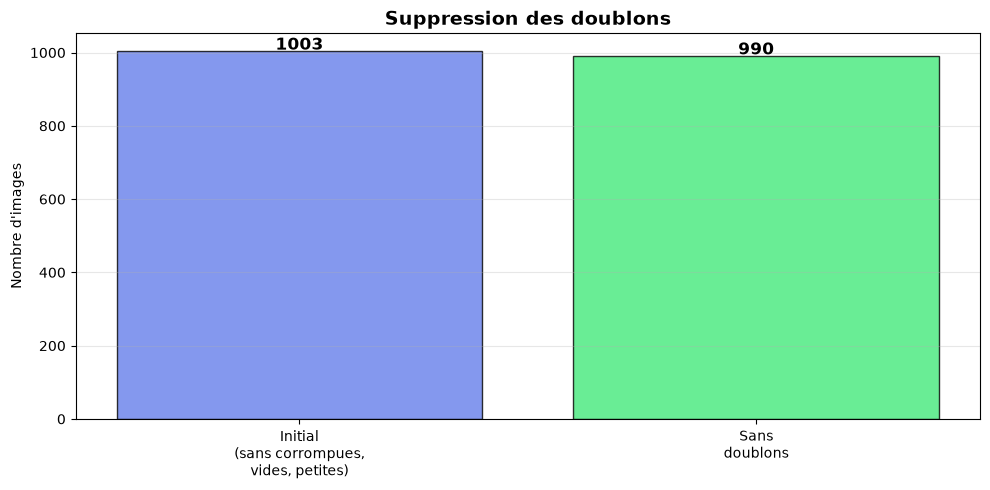

💾 Graphique sauvegardé dans '../reports/suppression_doublons.png'


In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

etapes = ['Initial\n(sans corrompues,\nvides, petites)', 'Sans\ndoublons']
valeurs = [len(df_sans_petites), len(df_sans_doublons)]
couleurs = ['#667eea', '#43e97b']

bars = ax.bar(etapes, valeurs, color=couleurs, edgecolor='black', alpha=0.8)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(val), ha='center', fontsize=12, fontweight='bold')

ax.set_title('Suppression des doublons', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre d\'images')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/suppression_doublons.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/suppression_doublons.png'")

In [52]:
print("=== VÉRIFICATION PARTIE 6 ===")
print(f"✅ Hash uniques : {df_sans_doublons['hash'].nunique()}")
print(f"✅ Total images : {len(df_sans_doublons)}")
print(f"✅ Doublons supprimés : {len(df_sans_petites) - len(df_sans_doublons)}")
print(f"✅ Vérification : {df_sans_doublons['hash'].nunique() == len(df_sans_doublons)}")

=== VÉRIFICATION PARTIE 6 ===
✅ Hash uniques : 990
✅ Total images : 990
✅ Doublons supprimés : 13
✅ Vérification : True


# Partie 7 – Détection des images mal classées

## 🎯 Objectif
Effectuer un **contrôle visuel** pour détecter les images qui ne correspondent **pas à leur classe**.

## 📝 Explication imagée

C'est comme vérifier que dans le **rayon "Fruits"** du supermarché, il n'y a pas de **légumes** qui traînent.

**Comment faire ?**
- On affiche un échantillon d'images de chaque classe
- On regarde visuellement si elles correspondent bien
- On note les erreurs dans une liste

**Note** : Cette étape est **manuelle** (on ne peut pas automatiser la détection sémantique facilement).

**Astuce** : On peut utiliser un **modèle pré-entraîné** (comme MobileNet) pour aider, mais pour cet atelier on fait un contrôle visuel simple.

In [55]:
import matplotlib.pyplot as plt
from PIL import Image

def afficher_echantillon(df, classe, nb=6):
    """Affiche un échantillon d'images d'une classe."""
    images = df[df['classe'] == classe].head(nb)
    
    if len(images) == 0:
        print(f"⚠️ Aucune image pour la classe {classe}")
        return
    
    fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
    
    if len(images) == 1:
        axes = [axes]
    
    for i, (_, row) in enumerate(images.iterrows()):
        try:
            img = Image.open(row['chemin'])
            axes[i].imshow(img)
            axes[i].set_title(f"{row['nom'][:15]}...", fontsize=9)
            axes[i].axis('off')
        except:
            axes[i].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            axes[i].axis('off')
    
    plt.suptitle(f"Classe : {classe}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/echantillon_{classe}.png', dpi=100, bbox_inches='tight')
    plt.show()

### Contrôle visuel des classes

Affichons un échantillon de chaque classe pour vérifier visuellement.

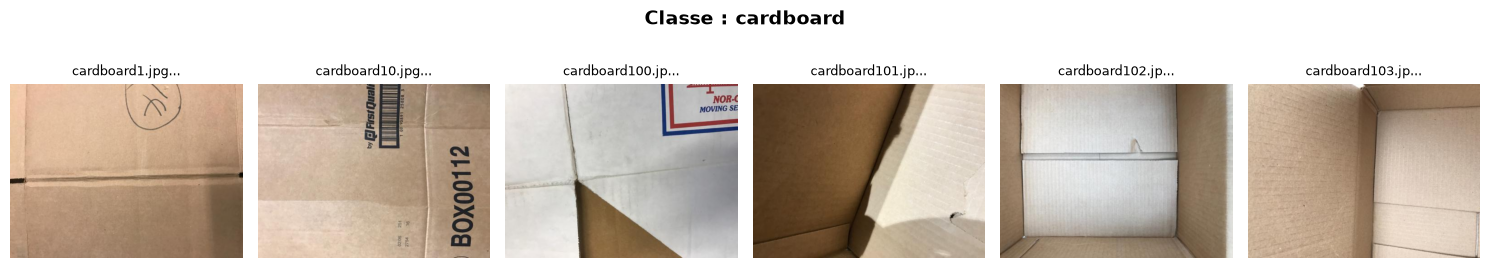

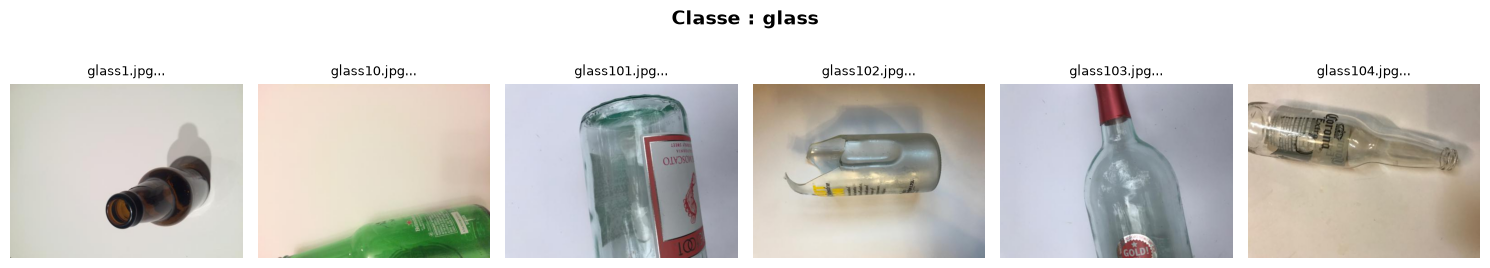

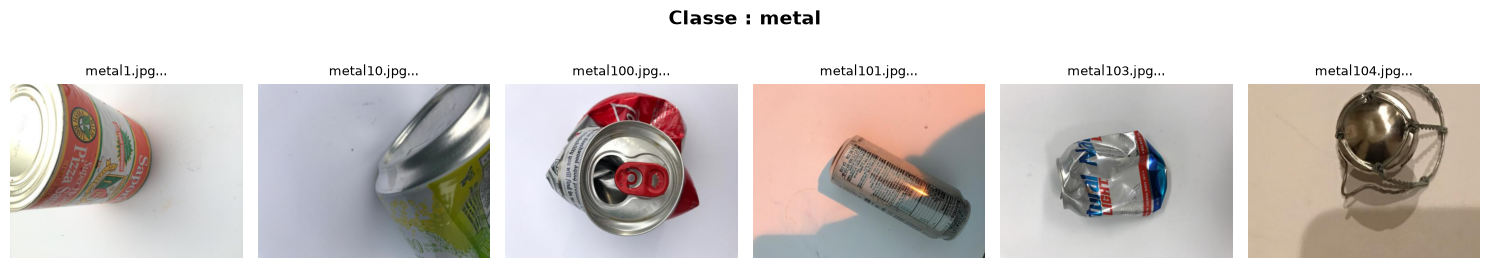

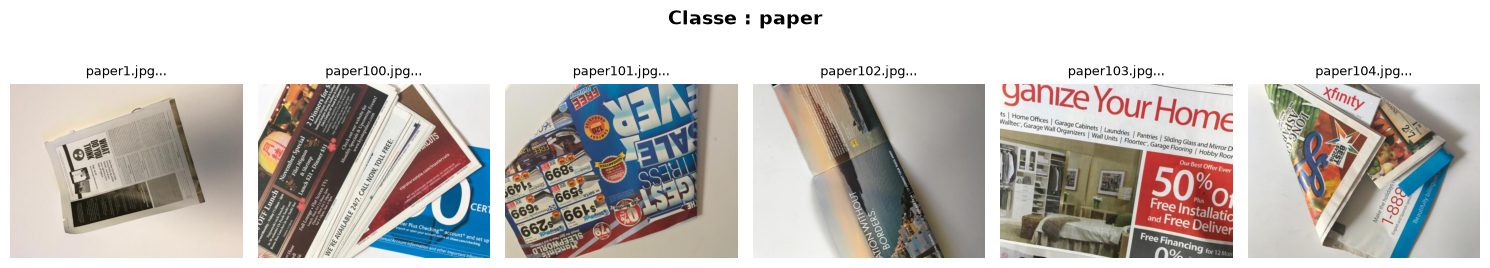

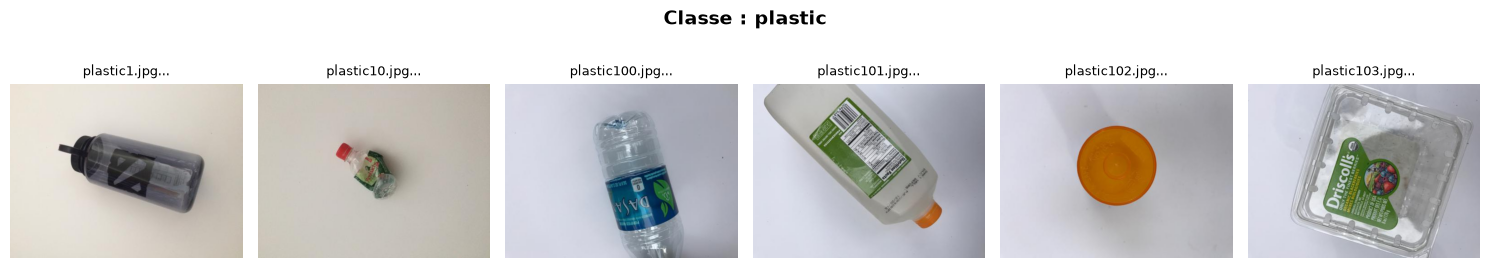

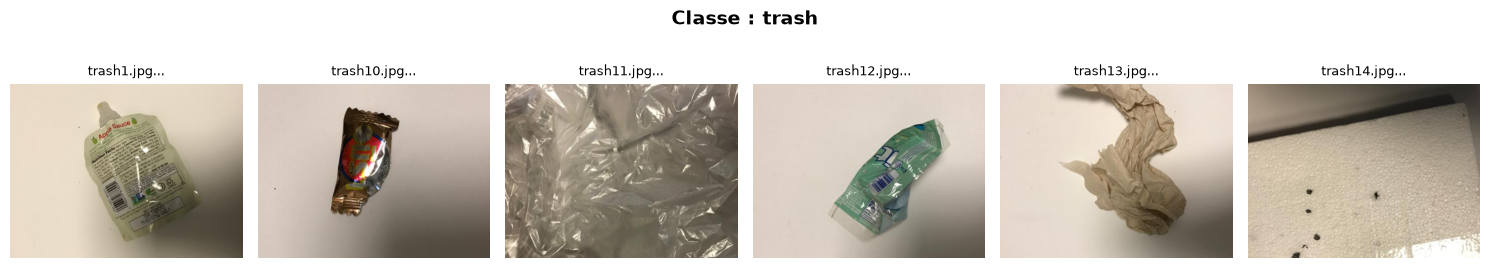

In [56]:
# Afficher un échantillon pour chaque classe
for classe in CLASSES:
    afficher_echantillon(df_sans_doublons, classe, nb=6)

### Liste des images suspectes

Après contrôle visuel, on note les images qui semblent mal classées.
**Remplacons les exemples ci-dessous par nos propres observations.**

In [57]:
# Liste des images suspectes (à remplir après contrôle visuel)
images_mal_classees = [
    # Exemples (à adapter selon vos observations) :
    # {'nom': 'image_123.jpg', 'classe_actuelle': 'cardboard', 'classe_correcte': 'paper'},
    # {'nom': 'image_456.jpg', 'classe_actuelle': 'plastic', 'classe_correcte': 'trash'},
]

print("=== IMAGES MAL CLASSÉES (contrôle visuel) ===\n")
print(f"⚠️  Nombre d'images suspectes : {len(images_mal_classees)}")

if len(images_mal_classees) > 0:
    for item in images_mal_classees:
        print(f"  - {item['nom']} : {item['classe_actuelle']} → {item['classe_correcte']}")
else:
    print("ℹ️  Aucune image mal classée détectée pour l'instant.")
    print("   Effectuez le contrôle visuel et remplissez la liste si nécessaire.")

=== IMAGES MAL CLASSÉES (contrôle visuel) ===

⚠️  Nombre d'images suspectes : 0
ℹ️  Aucune image mal classée détectée pour l'instant.
   Effectuez le contrôle visuel et remplissez la liste si nécessaire.


### Aide à la détection avec un modèle pré-entraîné (optionnel)

On peut utiliser **MobileNet** (pré-entraîné sur ImageNet) pour prédire la classe de chaque image. 
Si la prédiction est très différente de la classe réelle, c'est suspect.

In [58]:
# Cette cellule est optionnelle et nécessite tensorflow
try:
    from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
    from tensorflow.keras.preprocessing import image as keras_image
    
    print("✅ MobileNetV2 chargé")
    
    # Mapping des classes du dataset vers ImageNet (approximatif)
    mapping_imagenet = {
        'cardboard': ['carton', 'box', 'paper'],
        'glass': ['bottle', 'glass', 'jar'],
        'metal': ['can', 'tin', 'metal'],
        'paper': ['paper', 'book', 'newspaper'],
        'plastic': ['plastic', 'bottle', 'bag'],
        'trash': ['trash', 'garbage', 'waste']
    }
    
    print("\nℹ️  Pour utiliser la détection assistée :")
    print("   1. Charger MobileNetV2")
    print("   2. Prédire la classe de chaque image")
    print("   3. Comparer avec la classe réelle")
    print("   4. Signaler les incohérences")
    
except ImportError:
    print("⚠️ TensorFlow non installé. Détection assistée non disponible.")
    print("   Effectuez le contrôle visuel manuellement.")

✅ MobileNetV2 chargé

ℹ️  Pour utiliser la détection assistée :
   1. Charger MobileNetV2
   2. Prédire la classe de chaque image
   3. Comparer avec la classe réelle
   4. Signaler les incohérences


### Sauvegarde de l'état

On sauvegarde le dataset avec les images mal classées identifiées (si applicable).

In [59]:
# Ajouter une colonne pour marquer les images mal classées
df_sans_doublons['mal_classee'] = False

# Marquer les images identifiées
for item in images_mal_classees:
    masque = df_sans_doublons['nom'] == item['nom']
    df_sans_doublons.loc[masque, 'mal_classee'] = True

print("=== RÉCAPITULATIF PARTIE 7 ===\n")
print(f"📊 Total d'images : {len(df_sans_doublons)}")
print(f"⚠️  Images mal classées identifiées : {df_sans_doublons['mal_classee'].sum()}")
print(f"✅ Images valides : {len(df_sans_doublons) - df_sans_doublons['mal_classee'].sum()}")

# Sauvegarder
df_sans_doublons.to_csv('../reports/audit_images_final.csv', index=False)
print("\n💾 Sauvegardé dans '../reports/audit_images_final.csv'")

=== RÉCAPITULATIF PARTIE 7 ===

📊 Total d'images : 990
⚠️  Images mal classées identifiées : 0
✅ Images valides : 990

💾 Sauvegardé dans '../reports/audit_images_final.csv'


In [60]:
print("=== VÉRIFICATION PARTIE 7 ===")
print(f"✅ Contrôle visuel effectué")
print(f"✅ Images mal classées : {df_sans_doublons['mal_classee'].sum()}")
print(f"✅ Dataset final : {len(df_sans_doublons)} images")
print(f"✅ Fichier sauvegardé : audit_images_final.csv")

=== VÉRIFICATION PARTIE 7 ===
✅ Contrôle visuel effectué
✅ Images mal classées : 0
✅ Dataset final : 990 images
✅ Fichier sauvegardé : audit_images_final.csv


# Partie 8 – Analyse du déséquilibre des classes

## 🎯 Objectif
Déterminer combien d'images sont disponibles pour **chaque classe**, et identifier si certaines classes sont **sous-représentées**.

## 📝 Explication imagée

C'est comme compter les **joueurs d'une équipe** :
- Si une équipe a 50 attaquants et 2 gardiens → déséquilibre
- Le modèle apprendra mieux les classes avec beaucoup d'images
- Il faut **rééquilibrer** (data augmentation sur les classes minoritaires)

**Pourquoi c'est important ?**
- Un modèle entraîné sur des classes déséquilibrées aura tendance à **ignorer les classes minoritaires**
- Exemple : 90% de plastique et 10% de verre → le modèle prédira toujours "plastique"

In [61]:
print("=== NOMBRE D'IMAGES PAR CLASSE ===\n")

# Compter les images par classe
comptage = df_sans_doublons['classe'].value_counts().sort_index()

# Afficher avec pourcentages
total = len(df_sans_doublons)
for classe, nombre in comptage.items():
    pourcentage = nombre / total * 100
    barre = '█' * int(pourcentage / 2)
    print(f"📂 {classe:12s} : {nombre:5d} images ({pourcentage:5.2f}%) {barre}")

print(f"\n📊 Total : {total} images")

=== NOMBRE D'IMAGES PAR CLASSE ===

📂 cardboard    :   164 images (16.57%) ████████
📂 glass        :   180 images (18.18%) █████████
📂 metal        :   139 images (14.04%) ███████
📂 paper        :   245 images (24.75%) ████████████
📂 plastic      :   213 images (21.52%) ██████████
📂 trash        :    49 images ( 4.95%) ██

📊 Total : 990 images


### Identification des classes déséquilibrées

On calcule le **ratio** entre la classe majoritaire et la classe minoritaire.
- Ratio < 1.5 → équilibré ✅
- Ratio 1.5 à 3 → léger déséquilibre ⚠️
- Ratio > 3 → déséquilibre important ❌

In [62]:
print("=== ANALYSE DU DÉSÉQUILIBRE ===\n")

classe_max = comptage.idxmax()
classe_min = comptage.idxmin()
nb_max = comptage.max()
nb_min = comptage.min()
ratio = nb_max / nb_min

print(f"📈 Classe majoritaire : {classe_max} ({nb_max} images)")
print(f"📉 Classe minoritaire : {classe_min} ({nb_min} images)")
print(f"📊 Ratio max/min : {ratio:.2f}")

# Interprétation
if ratio < 1.5:
    print("\n✅ Dataset équilibré ! Aucune action nécessaire.")
elif ratio < 3:
    print("\n⚠️ Léger déséquilibre. Une data augmentation modérée peut aider.")
else:
    print("\n❌ Déséquilibre important ! Data augmentation nécessaire sur les classes minoritaires.")

# Écart à la moyenne
moyenne = comptage.mean()
print(f"\n📊 Moyenne par classe : {moyenne:.1f} images")
print("\nÉcart à la moyenne :")
for classe, nombre in comptage.items():
    ecart = nombre - moyenne
    symbole = '⬆️' if ecart > 0 else '⬇️'
    print(f"   {classe:12s} : {ecart:+6.1f} {symbole}")

=== ANALYSE DU DÉSÉQUILIBRE ===

📈 Classe majoritaire : paper (245 images)
📉 Classe minoritaire : trash (49 images)
📊 Ratio max/min : 5.00

❌ Déséquilibre important ! Data augmentation nécessaire sur les classes minoritaires.

📊 Moyenne par classe : 165.0 images

Écart à la moyenne :
   cardboard    :   -1.0 ⬇️
   glass        :  +15.0 ⬆️
   metal        :  -26.0 ⬇️
   paper        :  +80.0 ⬆️
   plastic      :  +48.0 ⬆️
   trash        : -116.0 ⬇️


### Visualisation du déséquilibre

Graphique en barres pour visualiser la répartition.

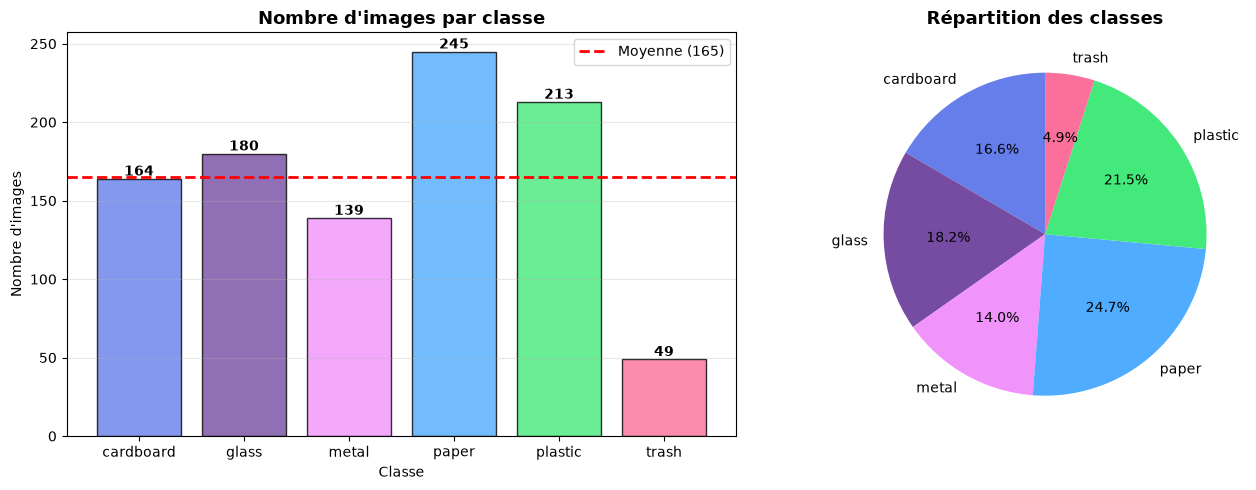

💾 Graphique sauvegardé dans '../reports/deséquilibre_classes.png'


In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres
couleurs = ['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b', '#fa709a']
bars = axes[0].bar(comptage.index, comptage.values, color=couleurs[:len(comptage)], edgecolor='black', alpha=0.8)

# Ligne de moyenne
axes[0].axhline(y=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne ({moyenne:.0f})')

# Ajouter les valeurs
for bar, val in zip(bars, comptage.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Nombre d\'images par classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'images')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Camembert
axes[1].pie(comptage.values, labels=comptage.index, autopct='%1.1f%%',
            colors=couleurs[:len(comptage)], startangle=90)
axes[1].set_title('Répartition des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/deséquilibre_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/deséquilibre_classes.png'")

### Stratégies de rééquilibrage (à retenir pour la Partie 13)

| Stratégie | Description | Quand l'utiliser |
|-----------|-------------|------------------|
| **Data Augmentation** | Créer des variations des images minoritaires | Ratio > 1.5 |
| **Class Weights** | Pénaliser plus les erreurs sur les classes minoritaires | Toujours utile |
| **Undersampling** | Réduire les classes majoritaires | Ratio très élevé |
| **Oversampling** | Dupliquer les classes minoritaires | Ratio très élevé |

**Pour cet atelier** : On utilisera la **Data Augmentation** en Partie 13.

In [64]:
print("=== VÉRIFICATION PARTIE 8 ===")
print(f"✅ Classes analysées : {len(comptage)}")
print(f"✅ Classe majoritaire : {classe_max} ({nb_max})")
print(f"✅ Classe minoritaire : {classe_min} ({nb_min})")
print(f"✅ Ratio : {ratio:.2f}")
print(f"✅ Graphique : deséquilibre_classes.png")

=== VÉRIFICATION PARTIE 8 ===
✅ Classes analysées : 6
✅ Classe majoritaire : paper (245)
✅ Classe minoritaire : trash (49)
✅ Ratio : 5.00
✅ Graphique : deséquilibre_classes.png


# Partie 9 – Redimensionnement

## 🎯 Objectif
Redimensionner **toutes** les images à une taille uniforme de **224 × 224 pixels**, avec :
- **Conservation des proportions** (pas de déformation)
- **Ajout de padding** (bordures) si nécessaire

## 📝 Explication imagée

C'est comme encadrer des **photos de tailles différentes** dans des cadres **tous identiques** :

- **Sans conservation des proportions** : On étire l'image → elle est déformée ❌
- **Avec conservation des proportions** : On garde la forme, on ajoute des bordures (padding) ✅

**Pourquoi 224×224 ?**
- C'est la taille standard pour de nombreux modèles pré-entraînés (ResNet, MobileNet, VGG...)
- C'est un bon compromis entre qualité et performance

**Formule de redimensionnement avec padding :**
1. Calculer le ratio = 224 / max(largeur, hauteur)
2. Redimensionner l'image en gardant ce ratio
3. Centrer l'image sur un fond (padding) de 224×224

In [65]:
def redimensionner_avec_padding(image, taille_cible=224, couleur_fond=(0, 0, 0)):
    """
    Redimensionne une image à taille_cible × taille_cible en conservant les proportions.
    Ajoute un padding (bordures) pour compléter.
    
    Paramètres:
    -----------
    image : PIL.Image - Image à redimensionner
    taille_cible : int - Taille cible (carrée)
    couleur_fond : tuple - Couleur du padding (R, G, B)
    
    Retourne:
    --------
    PIL.Image : Image redimensionnée avec padding
    """
    # Convertir en RGB pour uniformiser
    if image.mode != 'RGB':
        image = image.convert('RGB')
    
    largeur, hauteur = image.size
    
    # Calculer le ratio de redimensionnement
    ratio = taille_cible / max(largeur, hauteur)
    nouvelle_largeur = int(largeur * ratio)
    nouvelle_hauteur = int(hauteur * ratio)
    
    # Redimensionner en conservant les proportions
    image_redim = image.resize((nouvelle_largeur, nouvelle_hauteur), Image.LANCZOS)
    
    # Créer une image de fond (padding)
    image_finale = Image.new('RGB', (taille_cible, taille_cible), couleur_fond)
    
    # Centrer l'image redimensionnée sur le fond
    offset_x = (taille_cible - nouvelle_largeur) // 2
    offset_y = (taille_cible - nouvelle_hauteur) // 2
    image_finale.paste(image_redim, (offset_x, offset_y))
    
    return image_finale

### Test de la fonction

Testons la fonction sur une image pour vérifier le résultat.

=== TEST DE REDIMENSIONNEMENT ===

📷 Image originale : (512, 384) (L×H)
📷 Mode original : RGB

✅ Image redimensionnée : (224, 224)
✅ Mode : RGB


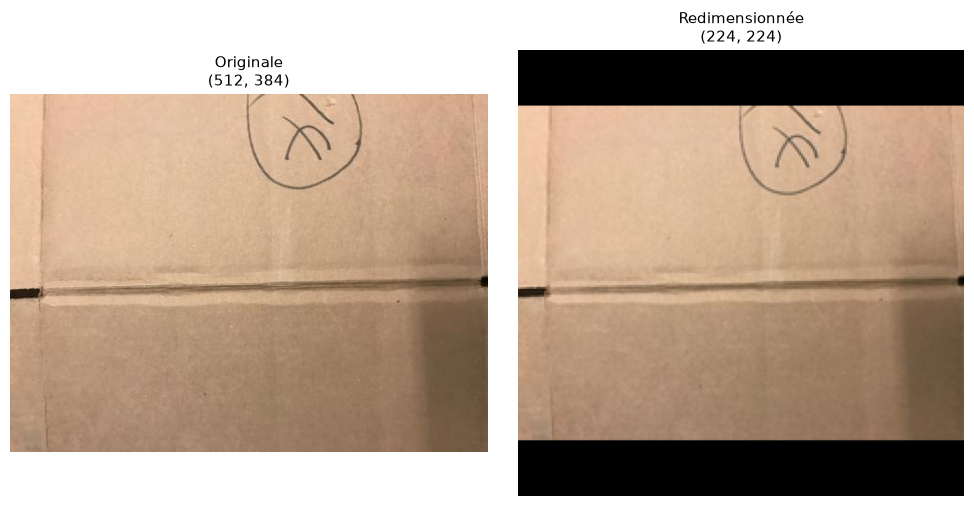

💾 Graphique sauvegardé dans '../reports/test_redimensionnement.png'


In [66]:
# Prendre une image au hasard
test_row = df_sans_doublons.iloc[0]
img_test = Image.open(test_row['chemin'])

print("=== TEST DE REDIMENSIONNEMENT ===\n")
print(f"📷 Image originale : {img_test.size} (L×H)")
print(f"📷 Mode original : {img_test.mode}")

# Redimensionner
img_redim = redimensionner_avec_padding(img_test, 224)

print(f"\n✅ Image redimensionnée : {img_redim.size}")
print(f"✅ Mode : {img_redim.mode}")

# Afficher la comparaison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_test)
axes[0].set_title(f'Originale\n{img_test.size}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_redim)
axes[1].set_title(f'Redimensionnée\n{img_redim.size}', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/test_redimensionnement.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/test_redimensionnement.png'")

### Traitement de toutes les images

On redimensionne **toutes** les images et on les sauvegarde dans `data/cleaned/`.

In [67]:
import os
from tqdm import tqdm

TAILLE_CIBLE = 224
CLEANED_DIR = '../data/cleaned'

# Créer les dossiers de sortie
for classe in CLASSES:
    os.makedirs(os.path.join(CLEANED_DIR, classe), exist_ok=True)

print("=== REDIMENSIONNEMENT DE TOUTES LES IMAGES ===\n")
print(f"📐 Taille cible : {TAILLE_CIBLE}×{TAILLE_CIBLE}\n")

erreurs = []
compteur = 0

# Traiter chaque image
for idx, row in tqdm(df_sans_doublons.iterrows(), total=len(df_sans_doublons), desc="Redimensionnement"):
    try:
        # Ouvrir l'image
        img = Image.open(row['chemin'])
        
        # Redimensionner
        img_redim = redimensionner_avec_padding(img, TAILLE_CIBLE)
        
        # Sauvegarder
        nom_sortie = f"{compteur:05d}_{row['nom']}.jpg"
        chemin_sortie = os.path.join(CLEANED_DIR, row['classe'], nom_sortie)
        img_redim.save(chemin_sortie, 'JPEG', quality=95)
        
        compteur += 1
        
    except Exception as e:
        erreurs.append({'nom': row['nom'], 'erreur': str(e)})

print(f"\n✅ Images redimensionnées : {compteur}")
print(f"❌ Erreurs : {len(erreurs)}")

if len(erreurs) > 0:
    print("\nDétail des erreurs :")
    for err in erreurs[:5]:
        print(f"  - {err['nom']} : {err['erreur']}")

=== REDIMENSIONNEMENT DE TOUTES LES IMAGES ===

📐 Taille cible : 224×224



Redimensionnement: 100%|██████████| 990/990 [00:17<00:00, 55.21it/s]


✅ Images redimensionnées : 990
❌ Erreurs : 0


### Vérification du résultat

On vérifie que toutes les images ont bien la taille 224×224.

In [68]:
print("=== VÉRIFICATION DU REDIMENSIONNEMENT ===\n")

# Compter les images par classe dans cleaned/
for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if os.path.exists(dossier):
        nb = len([f for f in os.listdir(dossier) if f.endswith('.jpg')])
        print(f"📂 {classe:12s} : {nb:5d} images")

# Vérifier la taille d'une image au hasard
import random
classe_test = random.choice(CLASSES)
dossier_test = os.path.join(CLEANED_DIR, classe_test)
if os.listdir(dossier_test):
    fichier_test = random.choice(os.listdir(dossier_test))
    img_test = Image.open(os.path.join(dossier_test, fichier_test))
    print(f"\n🔍 Vérification d'une image ({classe_test}) :")
    print(f"   Nom : {fichier_test}")
    print(f"   Taille : {img_test.size}")
    print(f"   Mode : {img_test.mode}")
    
    if img_test.size == (224, 224):
        print("   ✅ Taille correcte !")
    else:
        print("   ❌ Taille incorrecte !")

=== VÉRIFICATION DU REDIMENSIONNEMENT ===

📂 cardboard    :   164 images
📂 glass        :   180 images
📂 metal        :   139 images
📂 paper        :   245 images
📂 plastic      :   213 images
📂 trash        :    49 images

🔍 Vérification d'une image (plastic) :
   Nom : 00816_plastic184.jpg.jpg
   Taille : (224, 224)
   Mode : RGB
   ✅ Taille correcte !


In [69]:
print("=== VÉRIFICATION PARTIE 9 ===")
print(f"✅ Taille cible : {TAILLE_CIBLE}×{TAILLE_CIBLE}")
print(f"✅ Images traitées : {compteur}")
print(f"✅ Dossier de sortie : data/cleaned/")
print(f"✅ Conservation des proportions : OUI (padding)")
print(f"✅ Format de sortie : JPEG")

=== VÉRIFICATION PARTIE 9 ===
✅ Taille cible : 224×224
✅ Images traitées : 990
✅ Dossier de sortie : data/cleaned/
✅ Conservation des proportions : OUI (padding)
✅ Format de sortie : JPEG


### Visualisation avant / après redimensionnement

On affiche quelques images **avant** (taille originale) et **après** (224×224 avec padding).
Cela permet de vérifier que :
- Les proportions sont conservées
- Le padding est bien appliqué
- Les images ne sont pas déformées

In [70]:
import random

def afficher_comparaison_avant_apres(df, cleaned_dir, classe, nb=4):
    """Affiche une comparaison avant/après pour une classe."""
    images = df[df['classe'] == classe].head(nb)
    
    if len(images) == 0:
        print(f"⚠️ Aucune image pour la classe {classe}")
        return
    
    fig, axes = plt.subplots(2, len(images), figsize=(15, 6))
    
    if len(images) == 1:
        axes = axes.reshape(-1, 1)
    
    for i, (_, row) in enumerate(images.iterrows()):
        # Image originale
        try:
            img_orig = Image.open(row['chemin'])
            axes[0, i].imshow(img_orig)
            axes[0, i].set_title(f"Avant\n{img_orig.size}", fontsize=9)
            axes[0, i].axis('off')
        except:
            axes[0, i].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            axes[0, i].axis('off')
        
        # Image redimensionnée
        try:
            dossier_cleaned = os.path.join(cleaned_dir, classe)
            fichiers = sorted(os.listdir(dossier_cleaned))
            if i < len(fichiers):
                img_clean = Image.open(os.path.join(dossier_cleaned, fichiers[i]))
                axes[1, i].imshow(img_clean)
                axes[1, i].set_title(f"Après\n{img_clean.size}", fontsize=9)
                axes[1, i].axis('off')
        except Exception as e:
            axes[1, i].text(0.5, 0.5, 'Erreur', ha='center', va='center')
            axes[1, i].axis('off')
    
    plt.suptitle(f"Comparaison avant/après - {classe}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/comparaison_{classe}.png', dpi=100, bbox_inches='tight')
    plt.show()

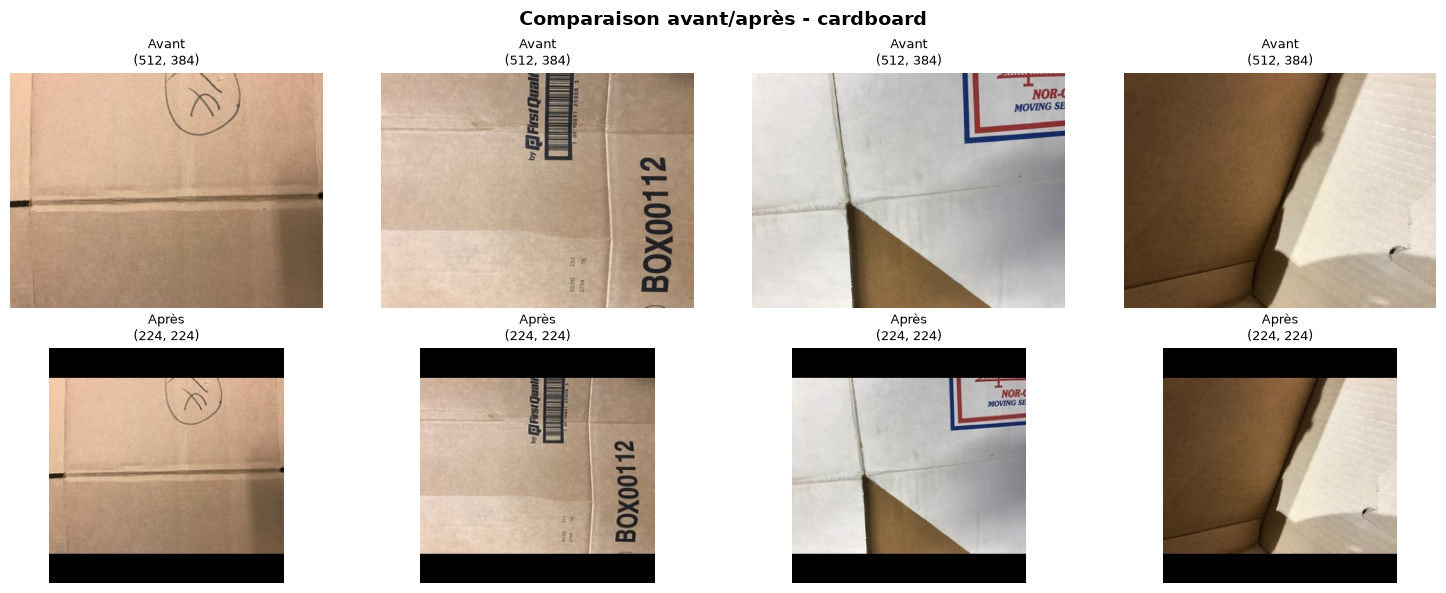

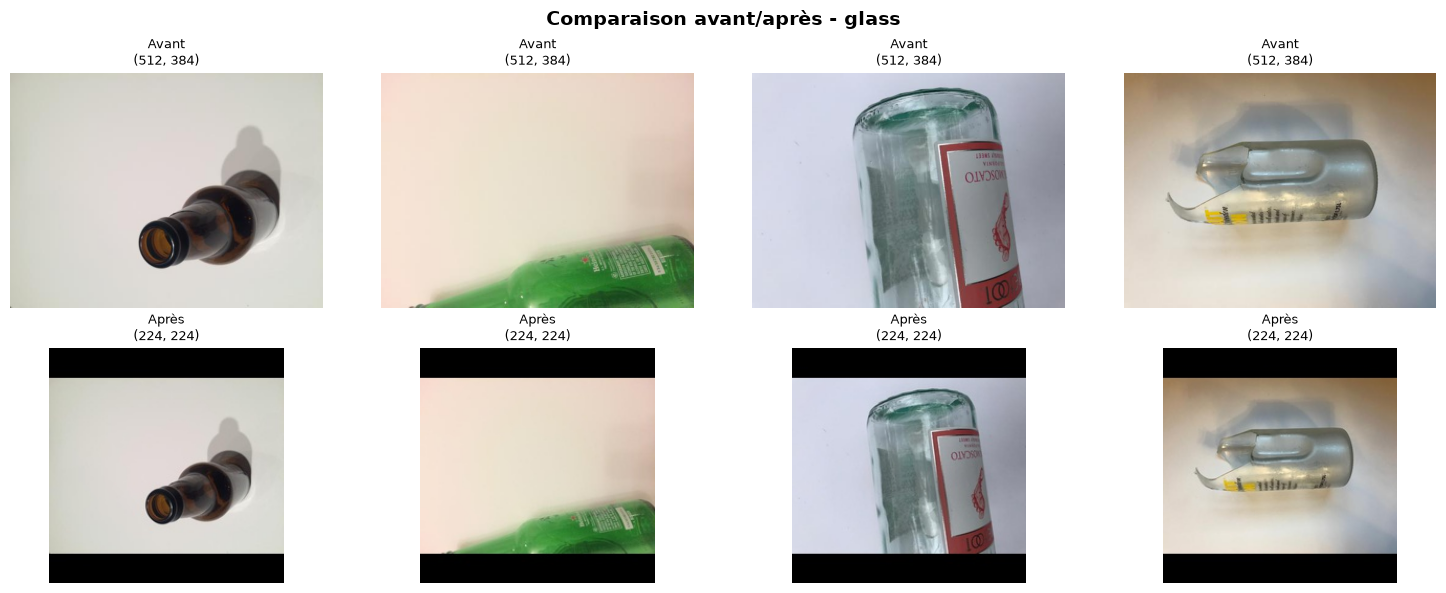

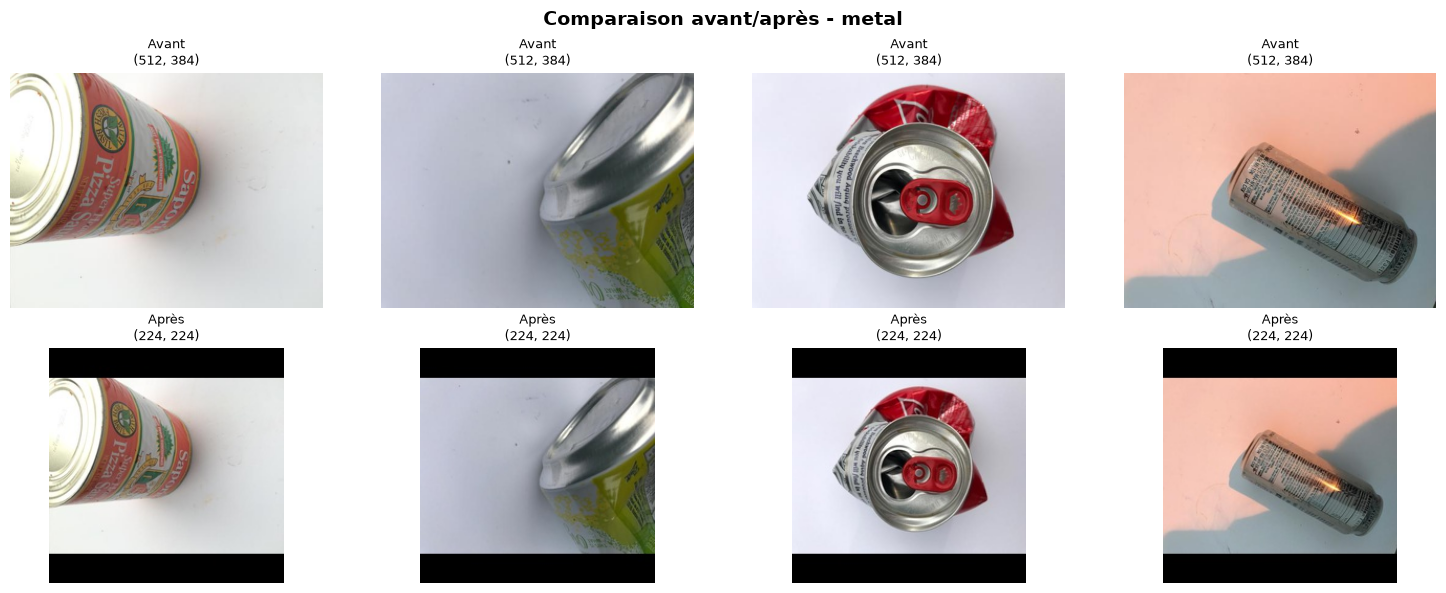

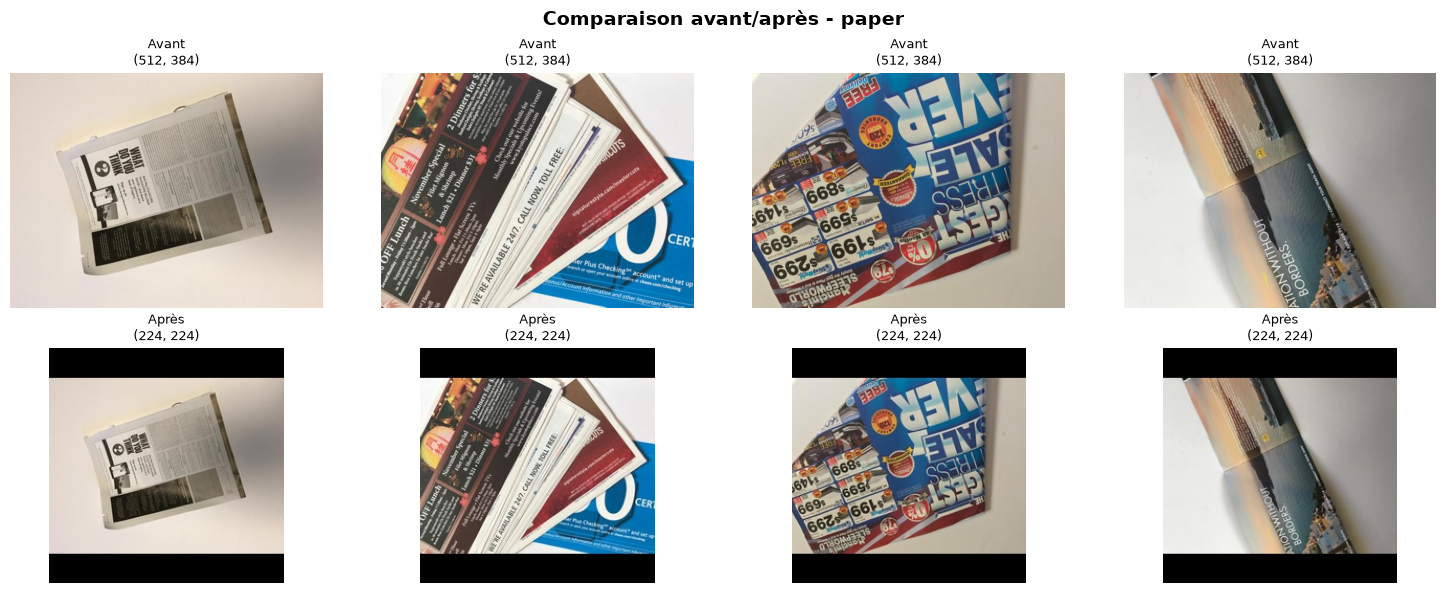

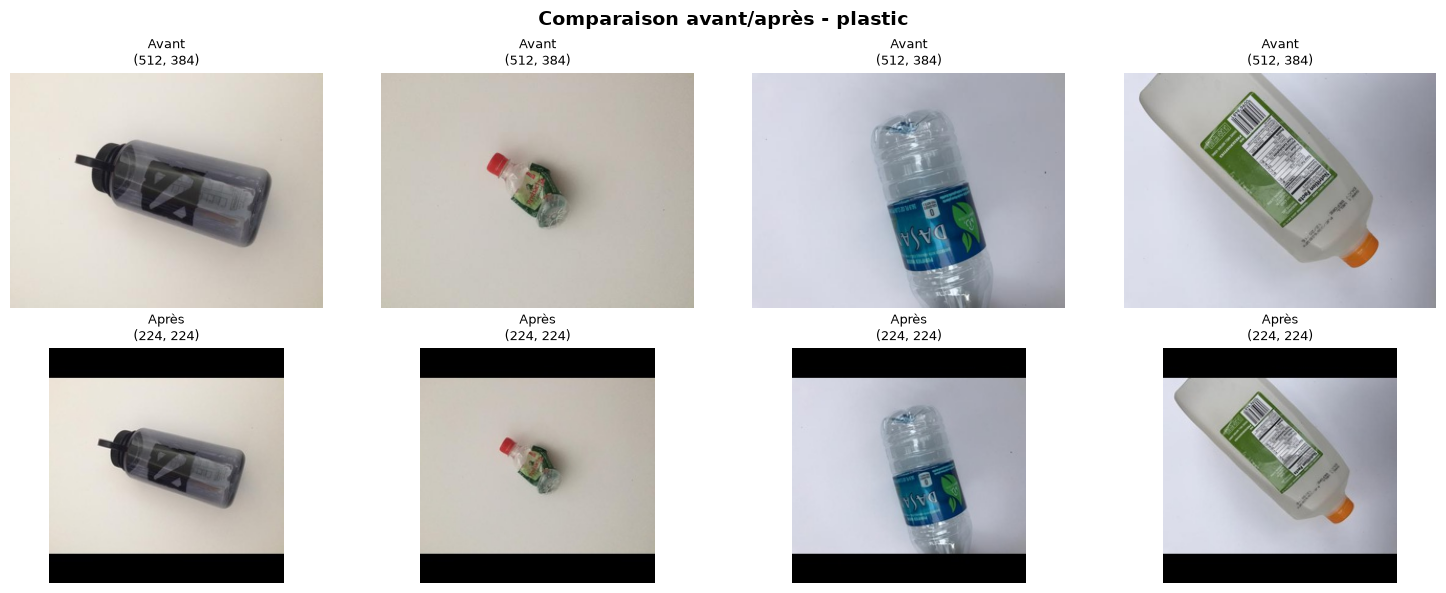

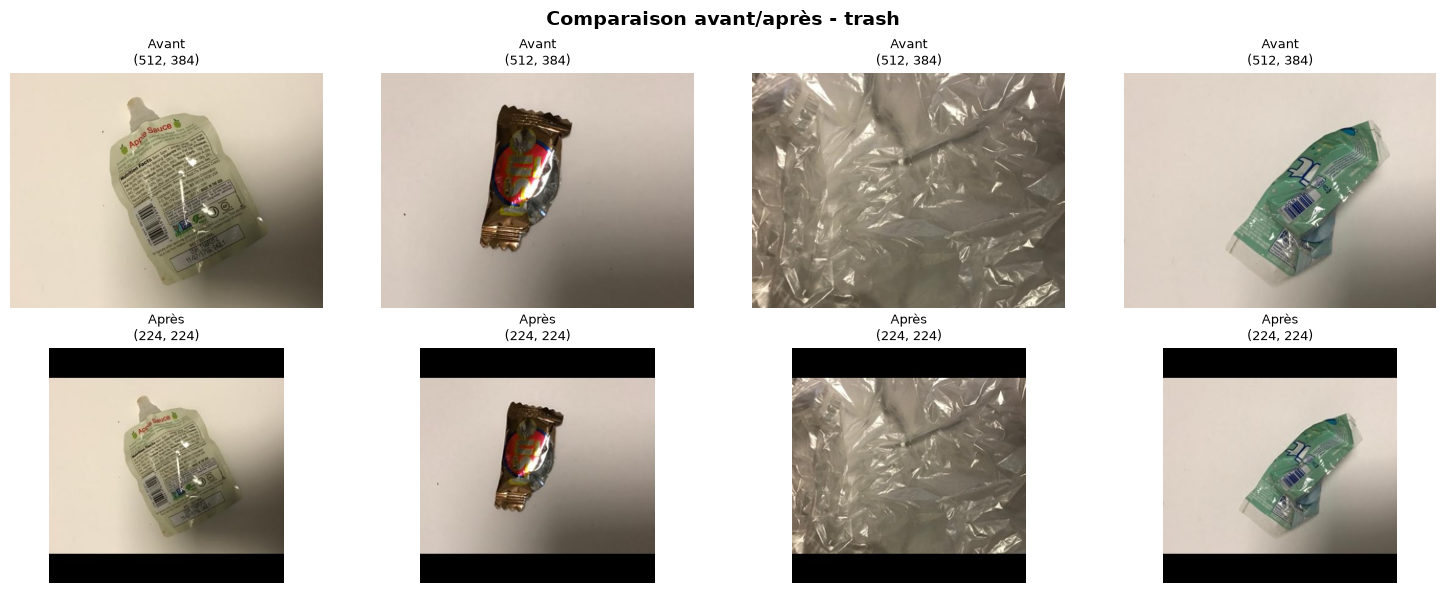

In [71]:
# Afficher la comparaison pour chaque classe
for classe in CLASSES:
    afficher_comparaison_avant_apres(df_sans_doublons, CLEANED_DIR, classe, nb=4)

### Vérification globale des dimensions

On parcourt toutes les images du dossier `cleaned/` pour vérifier qu'elles ont bien la taille 224×224.

In [72]:
print("=== VÉRIFICATION GLOBALE DES DIMENSIONS ===\n")

tailles = {}
erreurs = []

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    for fichier in os.listdir(dossier):
        if not fichier.endswith('.jpg'):
            continue
        try:
            img = Image.open(os.path.join(dossier, fichier))
            taille = img.size
            tailles[taille] = tailles.get(taille, 0) + 1
        except Exception as e:
            erreurs.append(fichier)

print("📐 Répartition des tailles :")
for taille, nombre in sorted(tailles.items(), key=lambda x: -x[1]):
    print(f"   {taille[0]}×{taille[1]} : {nombre} images")

if len(tailles) == 1 and list(tailles.keys())[0] == (224, 224):
    print("\n✅ Toutes les images ont la taille 224×224 !")
else:
    print(f"\n⚠️ {len(tailles)} tailles différentes détectées.")

print(f"\n❌ Images en erreur : {len(erreurs)}")

=== VÉRIFICATION GLOBALE DES DIMENSIONS ===

📐 Répartition des tailles :
   224×224 : 990 images

✅ Toutes les images ont la taille 224×224 !

❌ Images en erreur : 0


### Statistiques des fichiers générés

On vérifie la taille des fichiers et le nombre d'images par classe.

In [73]:
print("=== STATISTIQUES DES FICHIERS GÉNÉRÉS ===\n")

total_images = 0
total_taille = 0

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    fichiers = [f for f in os.listdir(dossier) if f.endswith('.jpg')]
    nb = len(fichiers)
    
    taille_classe = sum(os.path.getsize(os.path.join(dossier, f)) for f in fichiers)
    taille_mo = taille_classe / (1024 * 1024)
    
    total_images += nb
    total_taille += taille_classe
    
    print(f"📂 {classe:12s} : {nb:5d} images | {taille_mo:6.2f} Mo")

print(f"\n📊 TOTAL : {total_images} images | {total_taille / (1024*1024):.2f} Mo")

=== STATISTIQUES DES FICHIERS GÉNÉRÉS ===

📂 cardboard    :   164 images |   2.18 Mo
📂 glass        :   180 images |   1.92 Mo
📂 metal        :   139 images |   1.79 Mo
📂 paper        :   245 images |   3.68 Mo
📂 plastic      :   213 images |   2.23 Mo
📂 trash        :    49 images |   0.54 Mo

📊 TOTAL : 990 images | 12.33 Mo


In [74]:
print("=== VÉRIFICATION VISUELLE PARTIE 9 ===")
print(f"✅ Comparaisons avant/après générées pour chaque classe")
print(f"✅ Toutes les images font 224×224 : {list(tailles.keys()) == [(224, 224)]}")
print(f"✅ Nombre total d'images : {total_images}")
print(f"✅ Taille totale : {total_taille / (1024*1024):.2f} Mo")
print(f"✅ Fichiers de comparaison sauvegardés dans '../reports/'")

=== VÉRIFICATION VISUELLE PARTIE 9 ===
✅ Comparaisons avant/après générées pour chaque classe
✅ Toutes les images font 224×224 : True
✅ Nombre total d'images : 990
✅ Taille totale : 12.33 Mo
✅ Fichiers de comparaison sauvegardés dans '../reports/'


# Partie 10 – Uniformisation des canaux

## 🎯 Objectif
Convertir **toutes** les images en **RGB** (3 canaux) pour garantir que le modèle reçoive des données homogènes.

## 📝 Explication imagée

C'est comme demander à tout le monde de porter **le même uniforme** :
- Certains avaient des t-shirts à 1 couleur (gris)
- D'autres avaient des t-shirts à 4 couleurs (RGBA)
- On veut que **tout le monde** ait un t-shirt à 3 couleurs (RGB)

**Pourquoi uniformiser ?**
- Un modèle de Deep Learning attend **toujours** le même nombre de canaux
- Si on lui donne du gris (1 canal) puis du RGB (3 canaux), il est perdu
- On convertit donc tout en RGB : c'est la norme pour les modèles pré-entraînés

**Rappel des modes :**
- `L` : 1 canal (niveaux de gris)
- `RGB` : 3 canaux (Rouge, Vert, Bleu)
- `RGBA` : 4 canaux (RGB + Alpha/transparence)
- `P` : mode palette (couleurs indexées)

In [75]:
print("=== VÉRIFICATION DES MODES DANS CLEANED/ ===\n")

modes_cleaned = {}
erreurs = []

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    for fichier in os.listdir(dossier):
        if not fichier.endswith('.jpg'):
            continue
        try:
            img = Image.open(os.path.join(dossier, fichier))
            mode = img.mode
            modes_cleaned[mode] = modes_cleaned.get(mode, 0) + 1
        except Exception as e:
            erreurs.append(fichier)

print("📊 Répartition des modes :")
for mode, nombre in sorted(modes_cleaned.items(), key=lambda x: -x[1]):
    print(f"   {mode:6s} : {nombre:5d} images")

if len(modes_cleaned) == 1 and 'RGB' in modes_cleaned:
    print("\n✅ Toutes les images sont déjà en RGB !")
else:
    print(f"\n⚠️ {len(modes_cleaned)} modes différents détectés. Uniformisation nécessaire.")

=== VÉRIFICATION DES MODES DANS CLEANED/ ===

📊 Répartition des modes :
   RGB    :   990 images

✅ Toutes les images sont déjà en RGB !


### Fonction d'uniformisation

On crée une fonction qui convertit n'importe quelle image en RGB.

In [76]:
def convertir_en_rgb(image):
    """
    Convertit une image en RGB (3 canaux).
    
    Paramètres:
    -----------
    image : PIL.Image - Image à convertir
    
    Retourne:
    --------
    PIL.Image : Image en mode RGB
    """
    # Si déjà en RGB, on retourne tel quel
    if image.mode == 'RGB':
        return image
    
    # Si RGBA, on supprime la transparence en mettant un fond blanc
    if image.mode == 'RGBA':
        fond = Image.new('RGB', image.size, (255, 255, 255))
        fond.paste(image, mask=image.split()[3])  # Utilise le canal alpha comme masque
        return fond
    
    # Pour tous les autres modes (L, P, CMYK...), on convertit directement
    return image.convert('RGB')

### Test de la fonction

Testons la conversion sur quelques images.

=== TEST DE CONVERSION ===

📷 Mode original : RGBA
📷 Taille : (512, 384)

✅ Mode après conversion : RGB


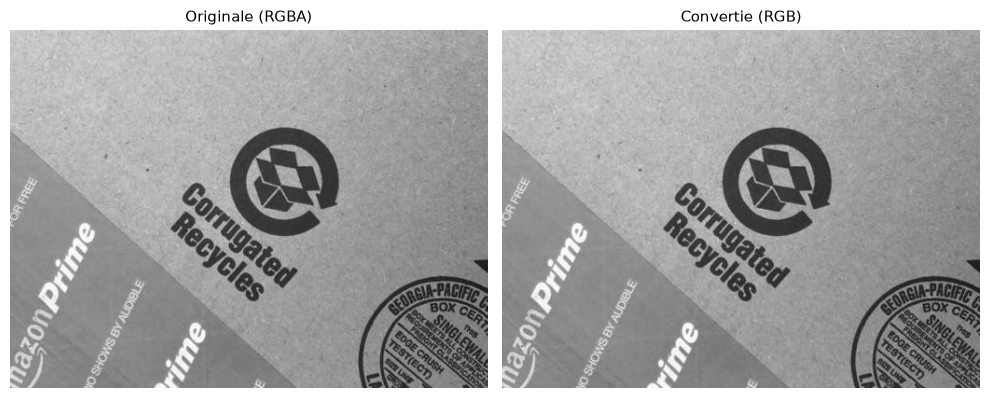

In [77]:
# Prendre une image non-RGB du dataset original
img_non_rgb = df_sans_doublons[df_sans_doublons['mode'] != 'RGB']

if len(img_non_rgb) > 0:
    test_row = img_non_rgb.iloc[0]
    img_test = Image.open(test_row['chemin'])
    
    print("=== TEST DE CONVERSION ===\n")
    print(f"📷 Mode original : {img_test.mode}")
    print(f"📷 Taille : {img_test.size}")
    
    # Convertir
    img_convertie = convertir_en_rgb(img_test)
    print(f"\n✅ Mode après conversion : {img_convertie.mode}")
    
    # Afficher la comparaison
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img_test, cmap='gray' if img_test.mode == 'L' else None)
    axes[0].set_title(f'Originale ({img_test.mode})', fontsize=11)
    axes[0].axis('off')
    
    axes[1].imshow(img_convertie)
    axes[1].set_title(f'Convertie ({img_convertie.mode})', fontsize=11)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig('../reports/test_conversion_rgb.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("✅ Aucune image non-RGB à convertir.")

### Conversion de toutes les images

On parcourt toutes les images de `cleaned/` et on les convertit en RGB.

In [78]:
from tqdm import tqdm

print("=== CONVERSION DE TOUTES LES IMAGES EN RGB ===\n")

conversions = 0
deja_rgb = 0
erreurs = []

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    fichiers = [f for f in os.listdir(dossier) if f.endswith('.jpg')]
    
    for fichier in tqdm(fichiers, desc=f"Classe {classe}", leave=False):
        chemin = os.path.join(dossier, fichier)
        try:
            img = Image.open(chemin)
            
            if img.mode == 'RGB':
                deja_rgb += 1
                continue
            
            # Convertir en RGB
            img_rgb = convertir_en_rgb(img)
            
            # Sauvegarder (écrase l'ancienne version)
            img_rgb.save(chemin, 'JPEG', quality=95)
            conversions += 1
            
        except Exception as e:
            erreurs.append({'fichier': fichier, 'erreur': str(e)})

print(f"\n✅ Conversions effectuées : {conversions}")
print(f"✅ Images déjà en RGB : {deja_rgb}")
print(f"❌ Erreurs : {len(erreurs)}")

=== CONVERSION DE TOUTES LES IMAGES EN RGB ===




✅ Conversions effectuées : 0
✅ Images déjà en RGB : 990
❌ Erreurs : 0


### Vérification finale

On vérifie que **toutes** les images sont maintenant en RGB.

In [79]:
print("=== VÉRIFICATION FINALE DES MODES ===\n")

modes_finaux = {}

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    for fichier in os.listdir(dossier):
        if not fichier.endswith('.jpg'):
            continue
        try:
            img = Image.open(os.path.join(dossier, fichier))
            mode = img.mode
            modes_finaux[mode] = modes_finaux.get(mode, 0) + 1
        except:
            pass

print("📊 Répartition des modes après uniformisation :")
for mode, nombre in sorted(modes_finaux.items(), key=lambda x: -x[1]):
    print(f"   {mode:6s} : {nombre:5d} images")

if list(modes_finaux.keys()) == ['RGB']:
    print("\n✅ Toutes les images sont en RGB !")
    print("✅ Uniformisation réussie.")
else:
    print(f"\n⚠️ {len(modes_finaux)} modes détectés. Vérifier manuellement.")

=== VÉRIFICATION FINALE DES MODES ===

📊 Répartition des modes après uniformisation :
   RGB    :   990 images

✅ Toutes les images sont en RGB !
✅ Uniformisation réussie.


### Visualisation

On affiche quelques images pour vérifier visuellement qu'elles sont bien en couleur.

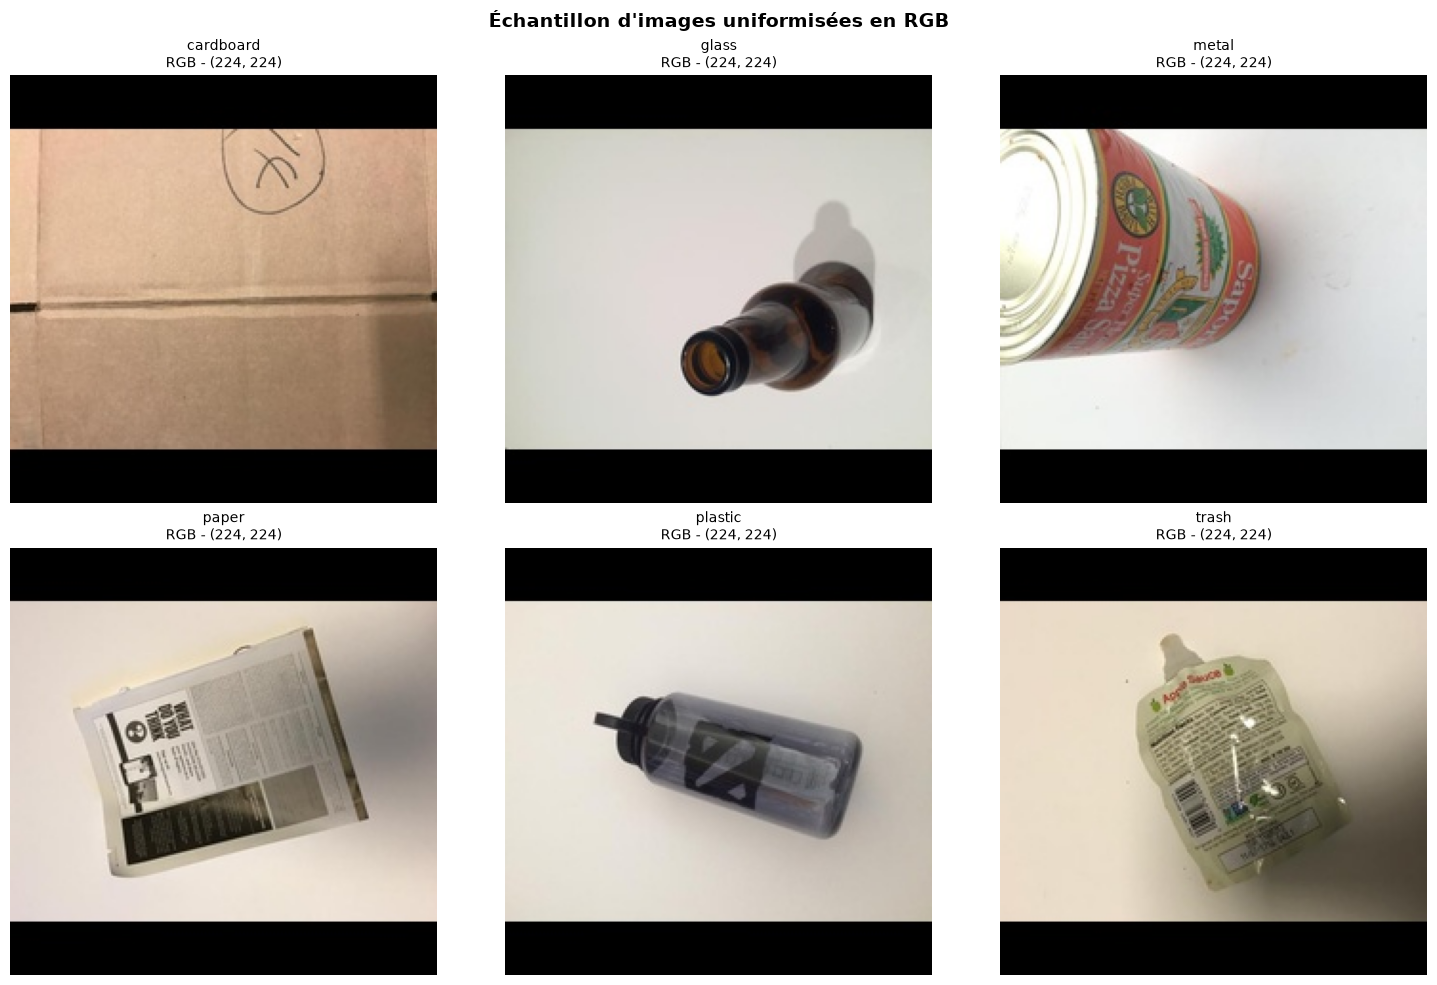

💾 Graphique sauvegardé dans '../reports/uniformisation_rgb.png'


In [80]:
# Afficher un échantillon d'images RGB
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, classe in enumerate(CLASSES):
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    fichiers = [f for f in os.listdir(dossier) if f.endswith('.jpg')]
    if len(fichiers) > 0:
        img = Image.open(os.path.join(dossier, fichiers[0]))
        
        ax = axes[i // 3, i % 3]
        ax.imshow(img)
        ax.set_title(f"{classe}\n{img.mode} - {img.size}", fontsize=10)
        ax.axis('off')

plt.suptitle('Échantillon d\'images uniformisées en RGB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/uniformisation_rgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/uniformisation_rgb.png'")

In [82]:
print("=== VÉRIFICATION PARTIE 10 ===")
print(f"✅ Conversions effectuées : {conversions}")
print(f"✅ Images déjà RGB : {deja_rgb}")
print(f"✅ Modes finaux : {list(modes_finaux.keys())}")
print(f"✅ Uniformisation : {'RÉUSSIE' if list(modes_finaux.keys()) == ['RGB'] else 'À VÉRIFIER'}")
print(f"✅ Dossier : data/cleaned/")

=== VÉRIFICATION PARTIE 10 ===
✅ Conversions effectuées : 0
✅ Images déjà RGB : 990
✅ Modes finaux : ['RGB']
✅ Uniformisation : RÉUSSIE
✅ Dossier : data/cleaned/


# Partie 11 – Mise à l'échelle des pixels

## 🎯 Objectif
Normaliser les valeurs des pixels de toutes les images pour qu'elles soient comprises entre **0 et 1** (au lieu de 0 à 255).

## 📝 Explication imagée

C'est comme convertir des **prix en centimes** en **prix en euros** :
- Avant : 255, 128, 64, 0 (valeurs brutes)
- Après : 1.0, 0.5, 0.25, 0.0 (valeurs normalisées)

**Pourquoi normaliser ?**
- Les modèles de Deep Learning apprennent **mieux et plus vite** avec des petites valeurs
- Cela évite que les gradients deviennent trop grands (explosion) ou trop petits (disparition)
- C'est une étape **obligatoire** avant l'entraînement

**Formule** : `pixel_normalisé = pixel / 255`

**Attention** : On ne modifie PAS les fichiers sur le disque. On applique la normalisation **au moment du chargement** pour l'entraînement.

In [83]:
print("=== VÉRIFICATION DES VALEURS AVANT NORMALISATION ===\n")

# Prendre une image au hasard
classe_test = random.choice(CLASSES)
dossier_test = os.path.join(CLEANED_DIR, classe_test)
fichier_test = random.choice([f for f in os.listdir(dossier_test) if f.endswith('.jpg')])
chemin_test = os.path.join(dossier_test, fichier_test)

# Charger l'image
img = Image.open(chemin_test)
pixels = np.array(img)

print(f"📷 Image test : {fichier_test}")
print(f"📐 Taille : {img.size}")
print(f"🎨 Mode : {img.mode}")
print(f"\n📊 Valeurs des pixels AVANT normalisation :")
print(f"   Minimum : {pixels.min()}")
print(f"   Maximum : {pixels.max()}")
print(f"   Moyenne : {pixels.mean():.2f}")
print(f"   Type : {pixels.dtype}")

=== VÉRIFICATION DES VALEURS AVANT NORMALISATION ===

📷 Image test : 00956_trash23.jpg.jpg
📐 Taille : (224, 224)
🎨 Mode : RGB

📊 Valeurs des pixels AVANT normalisation :
   Minimum : 0
   Maximum : 255
   Moyenne : 131.76
   Type : uint8


### Fonction de normalisation

On crée une fonction qui normalise les pixels d'une image entre 0 et 1.

In [84]:
def normaliser_image(image):
    """
    Normalise les pixels d'une image entre 0 et 1.
    
    Paramètres:
    -----------
    image : PIL.Image - Image à normaliser
    
    Retourne:
    --------
    np.array : Tableau numpy normalisé (float32)
    """
    # Convertir en tableau numpy
    pixels = np.array(image, dtype=np.float32)
    
    # Normaliser entre 0 et 1
    pixels_normalises = pixels / 255.0
    
    return pixels_normalises

### Test de la normalisation

Testons la fonction sur une image.

In [85]:
print("=== TEST DE NORMALISATION ===\n")

# Normaliser l'image test
pixels_normalises = normaliser_image(img)

print(f"📊 Valeurs des pixels APRÈS normalisation :")
print(f"   Minimum : {pixels_normalises.min():.4f}")
print(f"   Maximum : {pixels_normalises.max():.4f}")
print(f"   Moyenne : {pixels_normalises.mean():.4f}")
print(f"   Type : {pixels_normalises.dtype}")

# Vérifier que c'est bien entre 0 et 1
if pixels_normalises.min() >= 0 and pixels_normalises.max() <= 1:
    print("\n✅ Normalisation réussie : valeurs entre 0 et 1")
else:
    print("\n❌ Erreur de normalisation")

=== TEST DE NORMALISATION ===

📊 Valeurs des pixels APRÈS normalisation :
   Minimum : 0.0000
   Maximum : 1.0000
   Moyenne : 0.5167
   Type : float32

✅ Normalisation réussie : valeurs entre 0 et 1


### Visualisation de la distribution

On compare la distribution des pixels avant et après normalisation.

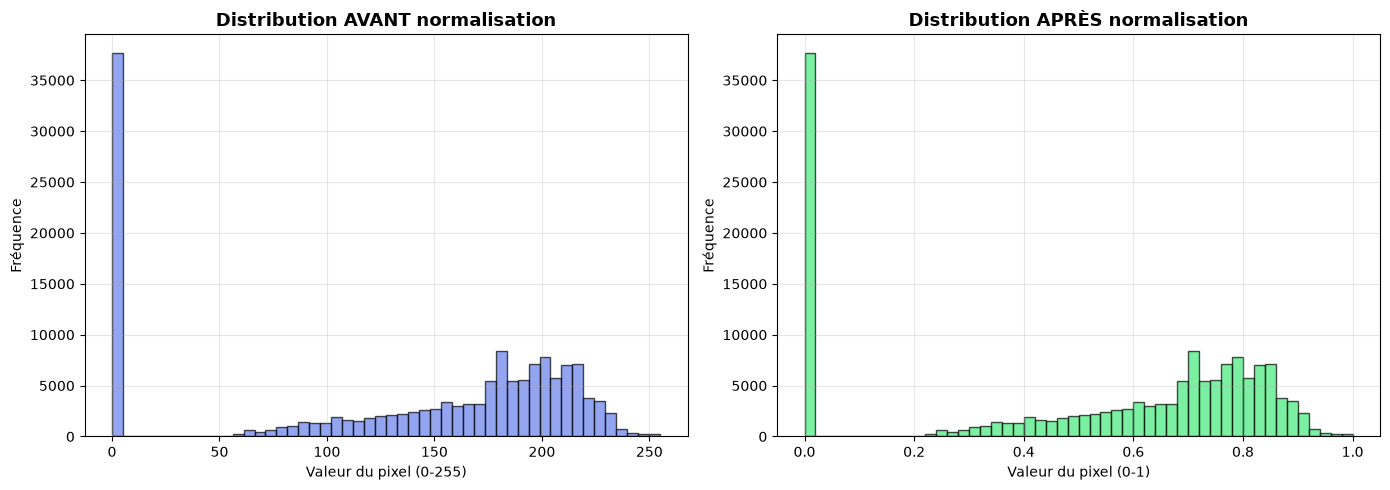

💾 Graphique sauvegardé dans '../reports/normalisation_pixels.png'


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution avant
axes[0].hist(pixels.flatten(), bins=50, color='#667eea', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution AVANT normalisation', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Valeur du pixel (0-255)')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

# Distribution après
axes[1].hist(pixels_normalises.flatten(), bins=50, color='#43e97b', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution APRÈS normalisation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valeur du pixel (0-1)')
axes[1].set_ylabel('Fréquence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/normalisation_pixels.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé dans '../reports/normalisation_pixels.png'")

### Application sur un lot d'images

On teste la normalisation sur plusieurs images pour vérifier la cohérence.

In [87]:
print("=== TEST SUR 10 IMAGES ===\n")

resultats = []

for classe in CLASSES:
    dossier = os.path.join(CLEANED_DIR, classe)
    if not os.path.exists(dossier):
        continue
    
    fichiers = [f for f in os.listdir(dossier) if f.endswith('.jpg')][:2]
    
    for fichier in fichiers:
        img = Image.open(os.path.join(dossier, fichier))
        pixels_norm = normaliser_image(img)
        
        resultats.append({
            'classe': classe,
            'fichier': fichier,
            'min': pixels_norm.min(),
            'max': pixels_norm.max(),
            'moyenne': pixels_norm.mean()
        })

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))

# Vérification globale
if df_resultats['min'].min() >= 0 and df_resultats['max'].max() <= 1:
    print("\n✅ Toutes les images sont correctement normalisées !")
else:
    print("\n⚠️ Certaines images ont des valeurs hors limites.")

=== TEST SUR 10 IMAGES ===

   classe                   fichier  min      max  moyenne
cardboard  00000_cardboard1.jpg.jpg  0.0 0.988235 0.462291
cardboard 00001_cardboard10.jpg.jpg  0.0 0.976471 0.482410
    glass      00164_glass1.jpg.jpg  0.0 0.945098 0.568019
    glass     00165_glass10.jpg.jpg  0.0 0.992157 0.577354
    metal      00344_metal1.jpg.jpg  0.0 1.000000 0.580151
    metal     00345_metal10.jpg.jpg  0.0 1.000000 0.453554
    paper      00483_paper1.jpg.jpg  0.0 0.976471 0.531928
    paper    00484_paper100.jpg.jpg  0.0 1.000000 0.419639
  plastic    00728_plastic1.jpg.jpg  0.0 0.968627 0.557424
  plastic   00729_plastic10.jpg.jpg  0.0 0.909804 0.546387
    trash      00941_trash1.jpg.jpg  0.0 1.000000 0.495006
    trash     00942_trash10.jpg.jpg  0.0 1.000000 0.462342

✅ Toutes les images sont correctement normalisées !


### Sauvegarde des paramètres

On sauvegarde les paramètres de normalisation pour les réutiliser plus tard.

In [88]:
# Paramètres de normalisation
parametres_normalisation = {
    'min_original': 0,
    'max_original': 255,
    'min_normalise': 0.0,
    'max_normalise': 1.0,
    'formule': 'pixel / 255.0'
}

# Sauvegarder dans un fichier JSON
import json

with open('../reports/parametres_normalisation.json', 'w') as f:
    json.dump(parametres_normalisation, f, indent=2)

print("=== PARAMÈTRES DE NORMALISATION ===\n")
for cle, valeur in parametres_normalisation.items():
    print(f"  {cle} : {valeur}")

print("\n💾 Sauvegardé dans '../reports/parametres_normalisation.json'")

=== PARAMÈTRES DE NORMALISATION ===

  min_original : 0
  max_original : 255
  min_normalise : 0.0
  max_normalise : 1.0
  formule : pixel / 255.0

💾 Sauvegardé dans '../reports/parametres_normalisation.json'


In [89]:
print("=== VÉRIFICATION PARTIE 11 ===")
print(f"✅ Fonction de normalisation : normaliser_image()")
print(f"✅ Plage de valeurs : [0, 1]")
print(f"✅ Type de données : float32")
print(f"✅ Formule : pixel / 255.0")
print(f"✅ Paramètres sauvegardés : parametres_normalisation.json")
print(f"\nℹ️  Note : Les fichiers sur le disque restent en 0-255.")
print(f"   La normalisation sera appliquée au chargement pour l'entraînement.")

=== VÉRIFICATION PARTIE 11 ===
✅ Fonction de normalisation : normaliser_image()
✅ Plage de valeurs : [0, 1]
✅ Type de données : float32
✅ Formule : pixel / 255.0
✅ Paramètres sauvegardés : parametres_normalisation.json

ℹ️  Note : Les fichiers sur le disque restent en 0-255.
   La normalisation sera appliquée au chargement pour l'entraînement.
